# Aula 5 — Regressão com Redes Neurais (MLP) e **Engenharia de Atributos Cíclicos**

## Estudo de caso: previsão da demanda de bicicletas compartilhadas

Baseado no exemplo oficial do scikit-learn:
[Time-related feature engineering](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html)

---

### O problema

Uma empresa de bicicletas compartilhadas precisa saber **quantas bicicletas serão alugadas na
próxima hora** para redistribuir a frota entre as estações. Temos dados horários de 2 anos com
informações de calendário (hora, dia da semana, mês, feriado) e de clima (temperatura, umidade,
vento).

É um problema de **regressão em série temporal**.

### A pergunta central da aula

> A coluna `hour` vale de 0 a 23. Para o modelo, `23` e `0` estão a **23 unidades de distância**.
> Mas no relógio eles são **vizinhos** (23h → 0h é 1 hora!).
> Como ensinar essa "circularidade" para a rede neural?

---

## Como a solução está organizada

O notebook segue as fases de um projeto real de ciência de dados. **Cada fase só usa o que a
anterior produziu** — nenhum número aparece antes de ser calculado.

| Fase | O que fazemos | O que ela entrega |
|------|---------------|-------------------|
| **FASE 1 — EDA** | Análise exploratória: olhar os dados sem modificá-los | Lista de **achados** e as **decisões** que eles justificam |
| **FASE 2 — Preparação e protocolo** | Montar `X`/`y`, definir a validação e as métricas | Um **protocolo de avaliação** e os **baselines de referência** |
| **FASE 3 — Modelagem** | 4 formas de codificar o tempo, com a mesma rede | O **impacto medido** de cada codificação |
| **FASE 4 — Diagnóstico** | Linear × rede neural e análise das previsões | **Entendimento** de por que o melhor modelo é melhor |
| **FASE 5 — Fechamento** | Conclusões e exercícios | O que levar para a próxima aula |

### Regra de ouro que vamos seguir

> **Nenhuma afirmação numérica sem a célula que a produz.**
> Se o texto diz "o erro é X", existe uma célula acima que calculou X.
> Se o número ainda não pode ser calculado nesta fase, o texto **aponta para a fase**
> em que ele será obtido.

---
---

# 🔍 FASE 1 — ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

**O que é o EDA?** É a fase em que **olhamos** os dados antes de modelar qualquer coisa.
Não treinamos nada aqui. Não transformamos nada aqui. Só investigamos.

**Por que ele vem primeiro?** Porque toda decisão técnica das fases seguintes — qual métrica
usar, como validar, como codificar as variáveis, qual modelo faz sentido — precisa ser
**justificada por uma evidência nos dados**, e não por hábito ou por cópia de tutorial.

### As 6 perguntas que este EDA precisa responder

| # | Pergunta | Onde respondemos |
|---|----------|------------------|
| 1 | O que são esses dados e qual o seu tamanho? | §1.1 |
| 2 | Dá para confiar neles? (faltantes, duplicatas, buracos, valores estranhos) | §1.2 |
| 3 | Como se comporta a variável que queremos prever? | §1.3 |
| 4 | Que padrões temporais existem? | §1.4 |
| 5 | As variáveis de tempo têm alguma peculiaridade estrutural? | §1.5 |
| 6 | O clima ajuda a explicar a demanda? | §1.6 |

E no fim, §1.7 converte cada achado em uma **decisão de projeto**.

> ⚠️ **Disciplina do EDA:** nesta fase o `df` **não é modificado**. Encontramos problemas e os
> anotamos; as correções acontecem na FASE 2. Isso mantém rastreável *o que* foi alterado e
> *por quê*.

---
## §1.1 — Visão geral: o que são esses dados?

In [216]:
# Bibliotecas usadas na aula inteira
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# Deixa os gráficos maiores e menos poluídos
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 30)

In [217]:
# O download é feito uma única vez e fica em cache na máquina
bike_sharing = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
df = bike_sharing.frame

print("Formato (linhas, colunas):", df.shape)
df.head()

Formato (linhas, colunas): (17379, 13)


,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


### Dicionário de dados

| Coluna | Tipo | Significado |
|--------|------|-------------|
| `season` | categórica | estação do ano (`spring`, `summer`, `fall`, `winter`) |
| `year` | 0/1 | 0 = 2011, 1 = 2012 |
| `month` | 1–12 | mês — **cíclico** (dezembro é vizinho de janeiro) |
| `hour` | 0–23 | hora do dia — **cíclico** (23h é vizinho de 0h) |
| `holiday` | booleana | é feriado? |
| `weekday` | 0–6 | dia da semana — **cíclico** (sábado é vizinho de domingo) |
| `workingday` | booleana | é dia útil (nem fim de semana, nem feriado)? |
| `weather` | categórica | condição do tempo (`clear`, `misty`, `rain`, `heavy_rain`) |
| `temp` | float | temperatura em °C |
| `feel_temp` | float | sensação térmica em °C |
| `humidity` | float | umidade relativa (0–1) |
| `windspeed` | float | velocidade do vento |
| **`count`** | int | **ALVO**: nº de bicicletas alugadas naquela hora |

Repare que **três colunas são cíclicas**: `hour`, `weekday` e `month`.
São exatamente elas o foco da aula.

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   year        17379 non-null  int64   
 2   month       17379 non-null  int64   
 3   hour        17379 non-null  int64   
 4   holiday     17379 non-null  category
 5   weekday     17379 non-null  int64   
 6   workingday  17379 non-null  category
 7   weather     17379 non-null  category
 8   temp        17379 non-null  float64 
 9   feel_temp   17379 non-null  float64 
 10  humidity    17379 non-null  float64 
 11  windspeed   17379 non-null  float64 
 12  count       17379 non-null  int64   
dtypes: category(4), float64(4), int64(5)
memory usage: 1.3 MB


In [219]:
# Estatísticas descritivas das colunas NUMÉRICAS
df.describe().round(2)

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,count
count,17379.0,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00
mean,0.5,6.54,11.55,3.00,20.38,23.79,0.63,12.74,189.46
std,0.5,3.44,6.91,2.01,7.89,8.59,0.19,8.20,181.39
min,0.0,1.00,0.00,0.00,0.82,0.00,0.00,0.00,1.00
25%,0.0,4.00,6.00,1.00,13.94,16.66,0.48,7.00,40.00
50%,1.0,7.00,12.00,3.00,20.50,24.24,0.63,13.00,142.00
75%,1.0,10.00,18.00,5.00,27.06,31.06,0.78,17.00,281.00
max,1.0,12.00,23.00,6.00,41.00,50.00,1.00,57.00,977.00


In [220]:
# E das colunas CATEGÓRICAS (describe muda de comportamento conforme o tipo)
df.describe(include="category")

,season,holiday,workingday,weather
count,17379,17379,17379,17379
unique,4,2,2,4
top,fall,False,True,clear
freq,4496,16879,11865,11413


### 📌 Leitura das estatísticas descritivas

- **`count` (o alvo)** vai de **1 a 977** bicicletas por hora, com **média 189,5** e
  **mediana 142**. Média maior que mediana já sugere **assimetria** — investigamos em §1.3.
- **`hour`** vai de 0 a 23 e **`weekday`** de 0 a 6, como esperado. Mas repare: o `describe`
  calculou **média e desvio-padrão** dessas colunas. Média de hora do dia (11,5) e desvio-padrão
  de dia da semana são números **sem significado** — sinal de que o pandas está tratando como
  grandeza numérica algo que é **posição em um ciclo**. Guarde isto para §1.5.
- **`temp`** e **`feel_temp`** têm distribuições muito parecidas — suspeita de redundância,
  verificada em §1.6.
- Nas categóricas, `season` está bem distribuída (4 valores, ~4.300 cada), mas `weather` tem
  **4 valores com frequências muito desiguais** — investigamos em §1.2.

---
## §1.2 — Dá para confiar nesses dados?

Antes de tirar qualquer conclusão, precisamos saber se os dados estão íntegros. Vamos checar
quatro coisas, na ordem: **valores ausentes**, **duplicatas**, **buracos na linha do tempo** e
**valores suspeitos**.

In [221]:
# 1) Valores ausentes
print("Total de valores ausentes no dataset:", df.isna().sum().sum())
print()
print("Por coluna:")
print(df.isna().sum().to_string())

Total de valores ausentes no dataset: 0

Por coluna:
season        0
year          0
month         0
hour          0
holiday       0
weekday       0
workingday    0
weather       0
temp          0
feel_temp     0
humidity      0
windspeed     0
count         0


In [222]:
# 2) Duplicatas: linhas idênticas em TODAS as colunas
n_dup = df.duplicated().sum()
print("Linhas duplicadas:", n_dup)
print()
print("As linhas envolvidas (mostrando os pares):")
df[df.duplicated(keep=False)].sort_values(list(df.columns))

Linhas duplicadas: 2

As linhas envolvidas (mostrando os pares):


,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
13559,fall,1,7,4,False,2,True,clear,27.06,30.305,0.83,6.0032,6
13727,fall,1,7,4,False,2,True,clear,27.06,30.305,0.83,6.0032,6
7958,winter,0,12,6,False,6,False,clear,9.84,12.880,0.65,7.0015,11
8126,winter,0,12,6,False,6,False,clear,9.84,12.880,0.65,7.0015,11


### 🕵️ Cuidado com a conclusão apressada sobre duplicatas

O reflexo automático seria `df.drop_duplicates()`. **Seria um erro aqui.** Olhe os índices:

- linhas **7958** e **8126** → diferença de **168**
- linhas **13559** e **13727** → diferença de **168**

**168 = 24 × 7**, ou seja, **exatamente uma semana de distância**. São duas horas diferentes da
vida real (por exemplo, uma terça-feira às 4h e a terça seguinte às 4h) em que *por coincidência*
tudo bateu: mesma estação, mesmo clima, mesma temperatura, mesma umidade — e o mesmo número de
aluguéis.

Por que isso acontece? Porque **o dataset não tem uma coluna de data/hora explícita**. A
identidade de cada linha está apenas na sua **posição** na tabela. Duas horas distintas podem ter
valores idênticos em todas as 13 colunas sem que haja qualquer erro.

> **Regra prática:** em série temporal sem timestamp, "duplicata" não é sinônimo de erro.
> Investigue antes de apagar.

In [223]:
# 3) Buracos na linha do tempo: 2011 e 2012 têm quantas horas?
horas_esperadas = 365 * 24 + 366 * 24   # 2012 foi bissexto
print("Horas esperadas em 2011+2012 :", horas_esperadas)
print("Linhas no dataset            :", len(df))
print("Horas AUSENTES               :", horas_esperadas - len(df),
      f"({(horas_esperadas - len(df)) / horas_esperadas * 100:.1f}%)")

Horas esperadas em 2011+2012 : 17544
Linhas no dataset            : 17379
Horas AUSENTES               : 165 (0.9%)


In [224]:
# 4) Valores suspeitos nas variáveis contínuas
print("humidity == 0 :", (df["humidity"] == 0).sum(), "linhas  <- umidade zero não existe")
print("windspeed == 0:", (df["windspeed"] == 0).sum(), "linhas",
      f"({(df['windspeed'] == 0).mean() * 100:.1f}%)  <- vento exatamente zero, muito frequente")
print("count == 0    :", (df["count"] == 0).sum(), "linhas  <- nenhuma hora com zero aluguéis")
print()
print("Faixas observadas:")
print(df[["temp", "feel_temp", "humidity", "windspeed"]].agg(["min", "max"]).round(2).to_string())

humidity == 0 : 22 linhas  <- umidade zero não existe
windspeed == 0: 2180 linhas (12.5%)  <- vento exatamente zero, muito frequente
count == 0    : 0 linhas  <- nenhuma hora com zero aluguéis

Faixas observadas:
      temp  feel_temp  humidity  windspeed
min   0.82        0.0       0.0        0.0
max  41.00       50.0       1.0       57.0


### 📋 Achados de qualidade

| Achado | Gravidade | O que fazer |
|--------|-----------|-------------|
| **Zero valores ausentes** | ✅ ótimo | Nada. Não precisaremos de imputação. |
| **2 pares de linhas idênticas, a 168h de distância** | ✅ falso positivo | **Não remover** — são horas distintas com condições coincidentes. |
| **165 horas ausentes (0,9%)** | ⚠️ atenção | O histórico tem pequenos buracos. Consequência: "168 linhas atrás" **não é exatamente** "uma semana atrás". Isso afeta qualquer atributo de defasagem (*lag*) — voltaremos a isso na FASE 2 (§2.4). |
| **22 linhas com `humidity` = 0** | ⚠️ suspeito | Umidade relativa zero não ocorre na atmosfera; provável falha do sensor. São 0,1% dos dados — não vamos tratar, mas fica registrado. |
| **2.180 linhas com `windspeed` = 0 (12,5%)** | ⚠️ suspeito | Muito frequente para ser real; provavelmente o sensor tem um limite mínimo e reporta 0 abaixo dele. Registrado. |
| **`count` nunca é zero** | 📌 informativo | Sempre houve ao menos 1 aluguel por hora. Ainda assim, **a rede poderá prever valores negativos** — problema que reaparece na FASE 4. |

> Nenhuma dessas correções é aplicada agora: estamos na fase de **diagnóstico**.

---
## §1.3 — A variável-alvo: o que exatamente queremos prever?

Esta é a variável mais importante do projeto. Tudo — métrica, validação, arquitetura — se ajusta
ao comportamento dela.

### O alvo em duas unidades: por que normalizar?

Vamos prever `count / count.max()`, ou seja, a **fração da frota alugada** naquela hora
(um número entre 0 e 1), em vez do número absoluto.

Duas razões:

1. **Interpretação**: o erro (MAE) passa a ser lido como "fração da frota".
   Para converter em bicicletas, basta multiplicar por `count.max()`.
2. **Treinamento da rede**: redes neurais com `adam` convergem melhor quando entradas e saída
   estão em escalas pequenas e parecidas. Um alvo indo até ~977 geraria gradientes enormes.

In [225]:
frota_max = df["count"].max()
print("Máximo de bicicletas alugadas em uma hora:", frota_max)

y = df["count"] / frota_max
y.head()

Máximo de bicicletas alugadas em uma hora: 977


0    0.016377
1    0.040942
2    0.032753
3    0.013306
4    0.001024
Name: count, dtype: float64

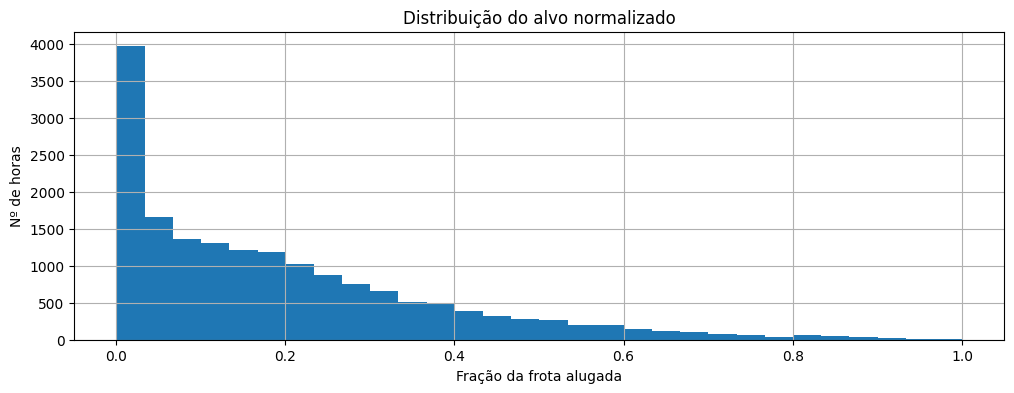

In [226]:
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    title="Distribuição do alvo normalizado",
    xlabel="Fração da frota alugada",
    ylabel="Nº de horas",
)

### 📊 Entendendo o histograma do alvo

#### O que este gráfico é — e o que ele **não** é

É o **histograma da variável-alvo**: daquilo que a rede vai tentar prever.

Um ponto conceitual importante: **este gráfico não fala de nenhuma variável de entrada**.
Ele não mostra relação entre duas coisas — não é dispersão, não é correlação.
Ele mostra **uma variável só**, respondendo à pergunta:

> *"Das 17.379 horas do histórico, quantas tiveram demanda baixa, média e alta?"*

- **Eixo X** = faixas de demanda (fração da frota). Multiplique por 977 para ler em bicicletas.
- **Eixo Y** = **número de horas** do histórico que caíram naquela faixa.
  Não é tempo, não é demanda: é **contagem de ocorrências**.

#### Linha a linha do código

| Código | O que faz |
|--------|-----------|
| `fig, ax = plt.subplots(figsize=(12, 4))` | Cria a figura e **um** sistema de eixos, de 12×4 polegadas. Ter o `ax` na mão é o que permite customizar os rótulos depois. |
| `y.hist(bins=30, ax=ax)` | O pandas divide o intervalo dos dados (0,001 a 1,0) em **30 faixas de igual largura** e conta quantas horas caem em cada uma. O `ax=ax` manda desenhar no eixo que criamos. |
| `_ = ax.set(...)` | Define título e rótulos. O `_ =` serve para **descartar o valor de retorno** — sem ele, o Jupyter imprimiria uma lista de objetos `Text` embaixo do gráfico. |

#### O que significa `bins=30`? (a parte que costuma travar)

**Um "bin" é uma gaveta.** `bins=30` manda o pandas pegar toda a faixa de valores existentes
e cortá-la em **30 pedaços de mesma largura**. Cada pedaço vira uma barra, e a altura da barra
é *quantas horas caíram naquele pedaço*.

A analogia mais direta é a de **notas de prova**. Com as notas de 500 alunos (0 a 100) e
`bins=10`, eu digo: *"crie 10 gavetas — 0 a 10, 10 a 20, 20 a 30... — e me diga quantos alunos
caem em cada uma"*. Cada gaveta tem **10 pontos de largura**, porque 100 ÷ 10 = 10.
Nenhum aluno tem "nota de gaveta": a gaveta é uma invenção do gráfico para agrupar valores parecidos.

**De onde sai a largura 0,0333**

É a mesma conta das notas, com os nossos dados:

```
menor valor de y ....... 0,001024   (=   1 bicicleta)
maior valor de y ....... 1,000000   (= 977 bicicletas)
amplitude .............. 0,998976   (o quanto os dados se espalham)

largura de cada gaveta = amplitude / 30 = 0,0333
```

Ou seja: cada barra ocupa **0,0333 de largura no eixo x**. Só isso.

**De onde sai o "32,5 bicicletas"**

Aqui está o pulo que costuma passar batido: `0,0333` e `32,5 bicicletas` são **a mesma largura**,
escrita em duas unidades diferentes — como dizer que uma mesa tem 1,5 m *ou* 150 cm.

Lembre que fizemos `y = count / 977`, então **o eixo x está em "frações de frota"**.
Para voltar à unidade original, desfazemos a divisão:

```
0,0333 x 977 = 32,5 bicicletas
```

**Por que essa conversão importa**

Sem ela, o eixo x é abstrato: você lê "0,0", "0,1", "0,2" — e o que é 0,0333 na vida real?
Com ela, cada barra ganha significado concreto:

| Barra | Faixa no eixo x | O que significa | Nº de horas |
|-------|-----------------|-----------------|-------------|
| 1ª | 0,0010 a 0,0343 | horas com **1 a 33 bicicletas** | 3.964 |
| 2ª | 0,0343 a 0,0676 | horas com **34 a 66 bicicletas** | 1.652 |
| 3ª | 0,0676 a 0,1009 | horas com **66 a 98 bicicletas** | 1.356 |
| ... | ... | ... | ... |
| 30ª | 0,9667 a 1,0000 | horas com **944 a 977 bicicletas** | 9 |

A soma de todas as alturas dá **17.379** — o total de linhas do dataset, porque toda hora
cai em alguma gaveta.

Agora a frase da primeira barra vira útil em aula: *"em 3.964 horas, quase um quarto do
histórico, alugaram-se no máximo 33 bicicletas"*. Antes da conversão só dava para dizer
*"3.964 horas tiveram y menor que 0,0343"*, que não significa nada para ninguém.

**`bins` é uma escolha sua, não um fato dos dados**

| `bins` | Largura de cada barra | 1ª barra cobre | Horas na 1ª barra |
|--------|-----------------------|----------------|-------------------|
| 5 | 195 bicicletas | 1 a 196 bikes | 10.677 |
| **30** | **32,5 bicicletas** | **1 a 34 bikes** | **3.964** |
| 200 | 4,9 bicicletas | 1 a 6 bikes | 1.081 |

Os **dados não mudaram** — só a régua. Com `bins=5` o gráfico fica grosseiro (uma única barra
engole 61% das horas e o formato se perde); com `bins=200` aparecem serrilhados que são ruído,
não padrão. `bins=30` é o meio-termo: fino o bastante para mostrar o decaimento, grosso o
bastante para não virar chuvisco.

A célula abaixo mostra essas contas saindo dos dados, em vez de aparecerem prontas.

#### Para que serve: 4 decisões que saem daqui

Este gráfico não é enfeite. Ele é feito **antes de treinar** porque determina quatro escolhas do projeto:

1. **Sanidade dos dados.** O alvo está no intervalo esperado? Há valores negativos, impossíveis,
   ou uma barra gigante em zero indicando falha de coleta? Aqui: mínimo de 1 e máximo de 977
   bicicletas, tudo plausível.
2. **Escolha da métrica.** Distribuição assimétrica com cauda longa → o RMSE ficaria dominado por
   poucas horas extremas. É este gráfico que justifica o **MAE** como métrica principal na FASE 2 (§2.3).
3. **Necessidade de transformar o alvo.** Assimetria forte costuma pedir raiz ou log no alvo.
4. **Ter a ordem de grandeza do problema.** A **largura** do histograma diz o quanto o alvo
   varia, e portanto se errar 5, 50 ou 500 bicicletas é pouco ou muito. Calculamos essa
   dispersão logo abaixo.
   ⚠️ **Mas dispersão do alvo não é erro de modelo.** O histograma **não** consegue dizer
   "a partir de que erro um modelo presta" — isso exige medir um modelo de verdade em dados
   que ele não viu, e só teremos protocolo para isso na **FASE 2 (§2.4)**.

---

### Roteiro de leitura em 5 passos

#### Passo 1 — Onde está a maior barra?

Na **primeira faixa**, colada no zero. E ela é enorme:

| Faixa (fração) | Em bicicletas | Nº de horas | % do total |
|----------------|---------------|-------------|------------|
| 0,001 – 0,034 | 1 a 33 | **3.964** | **22,8%** |
| 0,034 – 0,068 | 34 a 66 | 1.652 | 9,5% |
| 0,068 – 0,101 | 66 a 99 | 1.356 | 7,8% |

Quase **um quarto de todas as horas** teve menos de 34 bicicletas alugadas.
E 27,5% das horas ficaram abaixo de 49 bicicletas.

#### Passo 2 — Pergunte: "que horas são essas?"

Este é o pulo do gato: o histograma **levanta** a pergunta, mas quem responde é o
**conhecimento do domínio**. As horas dessa cauda esquerda são, em ordem de frequência:
**5h, 4h, 3h, 2h, 1h, 0h**. É a **madrugada**.

A barra gigante não é um defeito dos dados — é a cidade dormindo.

#### Passo 3 — Veja o decaimento à direita

As barras caem rápido e formam uma **cauda longa**:

- as **5 últimas faixas** somam apenas **118 horas** (0,7% do total);
- só **8% das horas** passaram de 489 bicicletas;
- essas horas de pico são **17h, 18h e 8h** — os horários de deslocamento casa–trabalho.

> 🕵️ **Um cuidado estatístico (veja a saída da célula acima).** 70,6% dessas horas de pico caem
> em dia útil — mas dias úteis já são **68,3%** de *todas* as horas do dataset. O percentual
> praticamente **repete a taxa-base**, portanto sozinho ele **não prova nada**. A evidência de
> verdade está em *quais* horas são (17h, 18h, 8h) e no gráfico de §1.4, que compara os
> **formatos** das curvas de dia útil e fim de semana.

São exatamente os picos de deslocamento casa–trabalho do gráfico da FASE 1 (§1.4).

> Os dois gráficos contam a mesma história por ângulos diferentes:
> o da FASE 1 (§1.4) mostra **quando** a demanda acontece;
> o histograma mostra **com que frequência** cada nível de demanda acontece.

#### Passo 4 — Compare média e mediana

| Estatística | Valor | Em bicicletas |
|-------------|-------|---------------|
| Mediana | 0,145 | 142 |
| Média | 0,194 | 190 |
| Assimetria (*skew*) | **+1,28** | — |

**Média > mediana** é a assinatura numérica da assimetria à direita: as poucas horas de pico
"puxam" a média para cima, e ela deixa de representar a hora típica.
Se o *skew* fosse ≈ 0, a distribuição seria simétrica; +1,28 é assimetria substancial.

#### Passo 5 — Tire as consequências para a modelagem

Aqui o gráfico deixa de ser descritivo e vira **decisão**:

- **A rede vê muito mais exemplos de demanda baixa do que alta.** Ela vai naturalmente acertar
  melhor a madrugada e **subestimar os picos** — é exatamente o que se confirma nos resíduos
  da FASE 4 (§4.2).
- **Isso importa para o negócio.** As 10% horas de maior demanda concentram **31% de todos os
  aluguéis**. O modelo é pior justamente onde o erro custa mais caro: sub-dimensionar a frota
  às 18h é perder cliente.
- **O que o histograma NÃO decide.** Ele dá a **escala** do problema, não a **meta** de
  desempenho. Repare que aqui ainda não existe modelo nenhum, nem separação entre treino e
  teste — logo, qualquer frase do tipo *"o modelo precisa errar menos que X"* seria um número
  tirado do nada. Essa régua é construída na **FASE 2 (§2.4)**, medindo dois modelos
  propositalmente burros sob o mesmo protocolo dos demais. Só a partir de lá um erro
  "de X bicicletas" pode ser julgado bom ou ruim.

---

### 💬 Perguntas para discussão

1. Se eu aumentar `bins` de 30 para 200, o gráfico muda? Alguma **conclusão** muda?
2. Por que o histograma **não começa em zero**?
   (O mínimo é 1 bicicleta: não existe hora com zero aluguel em 2 anos. Curiosamente, a rede
   **pode** prever valores negativos — daí o exercício 5.)
3. Como o gráfico ficaria se eu usasse `df["count"]` em vez de `y`?
   (Idêntico em forma; só o eixo x mudaria de escala — normalizar não altera a distribuição.)
4. Aplicando `np.sqrt(y)`, o que acontece com a assimetria?
   (Cai de **1,28 para 0,29**, quase simétrica: é a justificativa quantitativa do
   `TransformedTargetRegressor` do exercício 5.)

### ⚠️ Armadilhas comuns na leitura

- ❌ Ler o eixo Y como "quantidade de bicicletas". É **quantidade de horas**.
- ❌ Ler o eixo X como tempo. Não há tempo nenhum aqui — a ordem cronológica foi descartada.
- ❌ Concluir "os dados estão desbalanceados, preciso corrigir". A assimetria aqui é
  **um fato do mundo real**, não um defeito. Não se reamostra isso: adapta-se a métrica
  e, se quiser, transforma-se o alvo.

In [227]:
# De onde saem os números do histograma (rode e confira com a explicação acima)
amplitude = y.max() - y.min()
largura = amplitude / 30

print("menor valor de y :", round(y.min(), 6), f"(= {y.min() * frota_max:.0f} bicicleta)")
print("maior valor de y :", round(y.max(), 6), f"(= {y.max() * frota_max:.0f} bicicletas)")
print("amplitude        :", round(amplitude, 6))
print("largura da barra = amplitude / 30 =", round(largura, 4))
print("             ... x", frota_max, "=", round(largura * frota_max, 1), "bicicletas")

# np.histogram faz exatamente a mesma contagem que o gráfico, mas devolve os números
alturas, bordas = np.histogram(y, bins=30)

faixas = pd.DataFrame({
    "faixa em y": [f"[{bordas[i]:.4f}, {bordas[i+1]:.4f})" for i in range(30)],
    "faixa em bicicletas": [f"[{bordas[i] * frota_max:.0f}, {bordas[i+1] * frota_max:.0f})"
                            for i in range(30)],
    "nº de horas": alturas,
})

print()
print("Soma das alturas:", alturas.sum(), "= total de horas do dataset")
print()
print("Efeito da escolha de bins:")
for b in [5, 30, 200]:
    a, e = np.histogram(y, bins=b)
    print(f"  bins={b:>3}: cada barra = {(e[1] - e[0]) * frota_max:6.1f} bicicletas"
          f"  |  1a barra: {e[0] * frota_max:.0f} a {e[1] * frota_max:.0f} bikes,"
          f" com {a[0]:5d} horas")

# --- conferindo os demais números citados na explicação -------------------
bikes = y * frota_max

print()
print("Passo 1  horas com menos de 49 bicicletas :", (bikes < 49).sum(),
      f"({(bikes < 49).mean() * 100:.1f}%)")
print("Passo 3  horas nas 5 últimas faixas       :", alturas[-5:].sum(),
      f"({alturas[-5:].sum() / len(y) * 100:.1f}%)")
print("Passo 3  horas acima de 489 bicicletas    :", (bikes > 489).sum(),
      f"({(bikes > 489).mean() * 100:.1f}%)")

pico = df[bikes > 489]
print("Passo 3  horas do dia mais frequentes no pico:",
      pico["hour"].value_counts().head(3).index.tolist())
print("Passo 3  % das horas de pico em dia útil  :",
      f"{pico['workingday'].astype(str).eq('True').mean() * 100:.1f}%")
print("Passo 3  % de TODAS as horas em dia útil  :",
      f"{df['workingday'].astype(str).eq('True').mean() * 100:.1f}%  <- taxa-base, compare!")

n10 = int(len(y) * 0.1)
print("Passo 5  as 10% horas de maior demanda concentram",
      f"{y.nlargest(n10).sum() / y.sum() * 100:.1f}% de todos os aluguéis")

faixas.head(6)

menor valor de y : 0.001024 (= 1 bicicleta)
maior valor de y : 1.0 (= 977 bicicletas)
amplitude        : 0.998976
largura da barra = amplitude / 30 = 0.0333
             ... x 977 = 32.5 bicicletas

Soma das alturas: 17379 = total de horas do dataset

Efeito da escolha de bins:
  bins=  5: cada barra =  195.2 bicicletas  |  1a barra: 1 a 196 bikes, com 10677 horas
  bins= 30: cada barra =   32.5 bicicletas  |  1a barra: 1 a 34 bikes, com  3964 horas
  bins=200: cada barra =    4.9 bicicletas  |  1a barra: 1 a 6 bikes, com  1081 horas

Passo 1  horas com menos de 49 bicicletas : 4782 (27.5%)
Passo 3  horas nas 5 últimas faixas       : 118 (0.7%)
Passo 3  horas acima de 489 bicicletas    : 1386 (8.0%)
Passo 3  horas do dia mais frequentes no pico: [17, 18, 8]
Passo 3  % das horas de pico em dia útil  : 70.6%
Passo 3  % de TODAS as horas em dia útil  : 68.3%  <- taxa-base, compare!
Passo 5  as 10% horas de maior demanda concentram 31.3% de todos os aluguéis


,faixa em y,faixa em bicicletas,nº de horas
0,"[0.0010, 0.0343)","[1, 34)",3964
1,"[0.0343, 0.0676)","[34, 66)",1652
2,"[0.0676, 0.1009)","[66, 99)",1356
3,"[0.1009, 0.1342)","[99, 131)",1313
4,"[0.1342, 0.1675)","[131, 164)",1208
5,"[0.1675, 0.2008)","[164, 196)",1184


### A régua: qual é a "ordem de grandeza" do problema?

Antes de qualquer modelo, é útil saber **quanto o alvo varia**. Essa é uma pergunta puramente
descritiva, respondida pelo próprio histograma — e é o que a célula abaixo calcula.

In [228]:
# Medidas de DISPERSÃO do alvo (o quanto ele varia em torno do valor típico)
mediana = y.median()
desvio_abs_medio = (y - mediana).abs().mean()

print("Valor típico (mediana)                :", round(mediana, 4),
      f"-> {mediana * frota_max:.0f} bicicletas")
print("Desvio absoluto médio (em torno dela) :", round(desvio_abs_medio, 4),
      f"-> {desvio_abs_medio * frota_max:.0f} bicicletas")
print("Desvio-padrão                         :", round(y.std(), 4),
      f"-> {y.std() * frota_max:.0f} bicicletas")
print("Amplitude interquartil (IQR)          :", round(y.quantile(.75) - y.quantile(.25), 4),
      f"-> {(y.quantile(.75) - y.quantile(.25)) * frota_max:.0f} bicicletas")

Valor típico (mediana)                : 0.1453 -> 142 bicicletas
Desvio absoluto médio (em torno dela) : 0.1408 -> 138 bicicletas
Desvio-padrão                         : 0.1857 -> 181 bicicletas
Amplitude interquartil (IQR)          : 0.2467 -> 241 bicicletas


### ⚠️ O que esse número é — e o que ele **não** é

O desvio absoluto médio (~138 bicicletas) diz o seguinte:

> *"Se alguém, sem saber nada sobre hora, dia ou clima, chutasse sempre o valor típico,
> se afastaria do real em ~138 bicicletas, na média."*

É uma **medida de dispersão do alvo**, calculada **dentro da própria amostra** e **usando todos os
dados de uma vez**. Serve para dar **ordem de grandeza**: nos diz que um erro de 5 bicicletas
seria excelente e um erro de 200 seria péssimo.

**Mas ele ainda NÃO é o desempenho de um modelo**, e não pode ser comparado com os números das
FASES 3 e 4, por dois motivos:

1. **Dentro × fora da amostra.** Aqui a mediana foi calculada com os mesmos dados sobre os quais
   medimos o erro. Um modelo de verdade é avaliado em dados que **nunca viu**.
2. **O protocolo ainda não existe.** Só na FASE 2 definiremos como separar treino e teste. Sem
   isso, nenhum número é comparável com outro.

> Por isso o **baseline honesto** — um modelo que realmente chuta um valor constante, treinado e
> avaliado sob o mesmo protocolo dos demais — só aparece na **FASE 2 (§2.4)**. Você vai ver que o
> valor dele é **bem diferente** de 138, e o motivo é interessante.

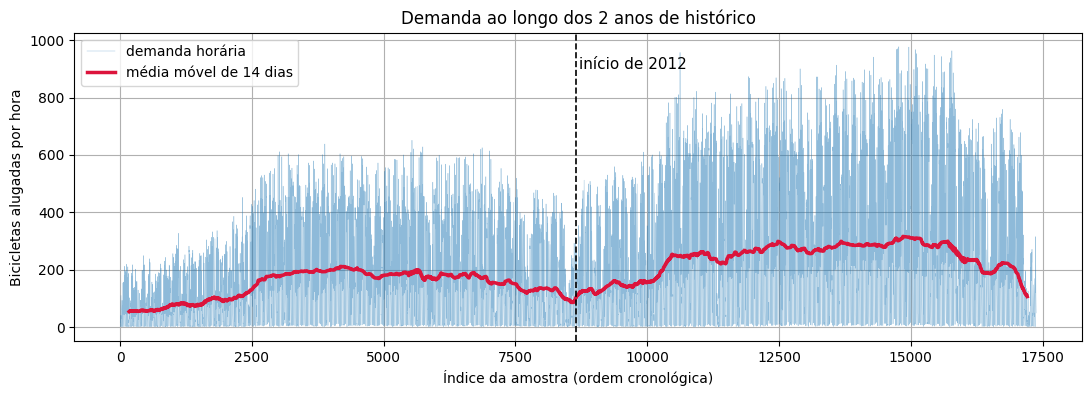

In [229]:
# Como o alvo evolui ao longo dos 2 anos?
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df["count"], lw=0.3, alpha=0.5, label="demanda horária")
ax.plot(df.index, df["count"].rolling(24 * 14, center=True).mean(),
        color="crimson", lw=2.5, label="média móvel de 14 dias")
ax.axvline(8645, color="k", ls="--", lw=1.2)
ax.text(8700, 900, "início de 2012", fontsize=11)
_ = ax.set(title="Demanda ao longo dos 2 anos de histórico",
           xlabel="Índice da amostra (ordem cronológica)",
           ylabel="Bicicletas alugadas por hora")
_ = ax.legend(loc="upper left")

### 🔎 Como ler este gráfico (o mais denso do EDA)

Ele parece simples, mas contém **três camadas de informação sobrepostas**. Vamos separá-las.

#### Linha a linha do código

| Código | O que faz |
|--------|-----------|
| `plt.subplots(figsize=(13, 4))` | Figura **larga e baixa**: são 17.379 pontos no eixo x. Em uma figura quadrada eles viram um borrão. |
| `ax.plot(df.index, df["count"], lw=0.3, alpha=0.5)` | Desenha **todas as 17.379 horas**. `lw=0.3` (linha finíssima) e `alpha=0.5` (semitransparente) transformam a série em uma **névoa** — sozinha ela seria ilegível. |
| `.rolling(24 * 14, center=True).mean()` | A **média móvel**: para cada hora, calcula a média das 336 horas ao redor. É o que revela o sinal lento. |
| `ax.axvline(8645, ls="--")` | Marca a **fronteira entre 2011 e 2012**. Por que 8645? É o índice da primeira linha com `year == 1` (a célula abaixo confere). |
| `ax.text(8700, 900, ...)` | Rótulo posicionado em coordenadas **dos dados** (x = índice 8700, y = 900 bicicletas), não da tela. |

#### Por que a janela é de 336 horas? (a decisão mais importante do código)

Não é um número redondo por acaso:

```
24 x 14 = 336 horas = 14 dias
336 / 24  = 14 ciclos diários  INTEIROS
336 / 168 =  2 ciclos semanais INTEIROS
```

Uma média móvel **cancela** um ciclo quando a janela cobre um número **inteiro** de repetições
dele: os picos de um dia compensam os vales do outro. Como 336 é múltiplo exato de 24 **e** de
168, esta janela apaga de uma vez o **ciclo diário** e o **ciclo semanal**, deixando visível
apenas o que varia devagar: **tendência e sazonalidade**.

> Se a janela fosse, digamos, 100 horas, ela cobriria 4 dias e um pedaço — sobraria resíduo do
> ciclo diário e a linha vermelha ficaria ondulada **artificialmente**, sugerindo um padrão que
> é só um artefato da média mal escolhida.

E o `center=True`? Ele alinha cada média ao **centro** da janela, e não ao fim.
Sem isso, a linha vermelha apareceria **atrasada** em ~7 dias em relação à azul.
O preço é que sobram **167 pontos sem valor em cada ponta** — por isso a linha vermelha
**não encosta nas bordas** do gráfico.

#### As três camadas, e o que cada uma revela

| Camada | No gráfico | O que ela mede |
|--------|------------|----------------|
| **Névoa azul** | a faixa preenchida | a variação **dentro do dia**. Sua **espessura** é a distância entre a madrugada e o pico. Em uma única semana a demanda vai de **1 a 556** bicicletas. |
| **Linha vermelha** | a curva grossa | o **sinal lento**: tendência + sazonalidade. Vai de **54** a **316** bicicletas/hora — uma variação de **5,9×**. |
| **Tracejado preto** | a vertical | a fronteira **2011 / 2012**, para comparar os dois anos a olho. |

#### O que ler, na ordem

1. **A ondulação** — a linha vermelha sobe no verão e cai no inverno, e faz isso **duas vezes**,
   uma por ano. Padrão que se repete = **sazonalidade anual**.
2. **O degrau** — a ondulação de 2012 acontece **inteira acima** da de 2011. Isso é
   **tendência de crescimento**: o serviço ganhando adoção. São **12 de 12 meses** maiores que o
   mês correspondente do ano anterior, com crescimento médio de **1,74×**.
3. **A névoa engorda junto com a linha** — quando a demanda média sobe, a variação absoluta
   também aumenta. Isso é típico de dados de contagem, e é a mesma assimetria que o histograma
   mostrou por outro ângulo.

#### ⚖️ Uma nuance que quase todo mundo passa batido

Tendência e sazonalidade **convivem**, e aqui a **sazonalidade é a mais forte**:

- oscilação sazonal: **5,9×** entre o melhor e o pior momento;
- crescimento anual: **1,74×**.

A prova: o **pior mês de 2012** (janeiro, 131 bicicletas/hora) ainda fica **abaixo** do
**melhor mês de 2011** (junho, 199). Ou seja, o crescimento não é forte o bastante para
"engolir" o inverno. O modelo vai precisar dos dois sinais: `year` para a tendência e `month`
para a sazonalidade.

#### ⚠️ Uma limitação honesta deste gráfico

O eixo x é o **índice da linha**, não uma data — o dataset não tem coluna de data/hora
(lembre do §1.2). E como faltam **165 horas**, o índice e o tempo real vão se desencontrando aos
poucos. Para leitura visual de tendência isso é irrelevante; para **datar um evento específico**
("o que houve naquele vale?"), o gráfico não serve.

A célula abaixo calcula todos os números citados acima.

In [230]:
# Quantificando o que o gráfico mostra
print(df.groupby("year")["count"].agg(["mean", "median", "max"]).round(1).to_string())
print()
crescimento = df[df.year == 1]["count"].median() / df[df.year == 0]["count"].median()
print(f"A mediana da demanda em 2012 é {crescimento:.2f}x a de 2011.")

print()
print("--- a linha vertical ---")
print("Primeiro índice de 2012 (year == 1):", df.index[df.year == 1][0])

print()
print("--- a janela da média móvel ---")
janela = 24 * 14
media_movel = df["count"].rolling(janela, center=True).mean()
print(f"{janela} horas = {janela // 24} dias")
print(f"   {janela} / 24  = {janela // 24} ciclos diários inteiros")
print(f"   {janela} / 168 = {janela // 168} ciclos semanais inteiros")
print("   pontos sem valor nas pontas (center=True):", media_movel.isna().sum(),
      f"= {media_movel.isna().sum() // 2} de cada lado")

print()
print("--- as camadas ---")
semana = df["count"].iloc[5000:5168]
print(f"Névoa azul  : em UMA semana a demanda vai de {semana.min()} a {semana.max()} bicicletas")
print(f"Linha vermelha: vai de {media_movel.min():.0f} a {media_movel.max():.0f} bicicletas/hora"
      f" -> variação de {media_movel.max() / media_movel.min():.1f}x")

print()
print("--- tendência x sazonalidade ---")
mensal = df.pivot_table(index="month", columns="year", values="count", aggfunc="mean").round(0)
mensal.columns = ["2011", "2012"]
mensal["razão"] = (mensal["2012"] / mensal["2011"]).round(2)
print(mensal.to_string())
print()
print("Meses em que 2012 superou 2011:", int((mensal["2012"] > mensal["2011"]).sum()), "de 12")
print("Crescimento médio:", round(mensal["razão"].mean(), 2), "x")
print(f"Pior mês de 2012: {mensal['2012'].min():.0f}  |  "
      f"Melhor mês de 2011: {mensal['2011'].max():.0f}"
      "   <- a sazonalidade é maior que a tendência")

       mean  median  max
year                    
0     143.8   109.0  651
1     234.7   191.0  977

A mediana da demanda em 2012 é 1.75x a de 2011.

--- a linha vertical ---
Primeiro índice de 2012 (year == 1): 8645

--- a janela da média móvel ---
336 horas = 14 dias
   336 / 24  = 14 ciclos diários inteiros
   336 / 168 = 2 ciclos semanais inteiros
   pontos sem valor nas pontas (center=True): 335 = 167 de cada lado

--- as camadas ---
Névoa azul  : em UMA semana a demanda vai de 1 a 556 bicicletas
Linha vermelha: vai de 54 a 316 bicicletas/hora -> variação de 5.9x

--- tendência x sazonalidade ---
        2011   2012  razão
month                     
1       56.0  131.0   2.34
2       74.0  149.0   2.01
3       88.0  222.0   2.52
4      132.0  243.0   1.84
5      183.0  263.0   1.44
6      199.0  282.0   1.42
7      190.0  274.0   1.44
8      187.0  288.0   1.54
9      178.0  304.0   1.71
10     166.0  281.0   1.69
11     142.0  213.0   1.50
12     118.0  167.0   1.42

Meses em que

### 📌 Achado crítico: a série **não é estacionária**

A média móvel mostra duas coisas sobrepostas:

1. **Sazonalidade anual**: sobe no verão, cai no inverno — o padrão se repete nos dois anos.
2. **Tendência de crescimento**: 2012 inteiro está acima de 2011. A mediana **quase dobra**
   (109 → 191 bicicletas). O serviço estava sendo adotado pela população.

**Por que isso muda o projeto inteiro:**

- **Não podemos embaralhar os dados.** Treinar com 2012 para prever 2011 seria trapaça: o modelo
  saberia de um crescimento que, na data da previsão, ainda não tinha acontecido. Isso decide a
  validação da FASE 2 (§2.2).
- **A coluna `year` é informativa** — ela carrega essa tendência.
- **Prever o futuro é mais difícil do que descrever o passado.** Qualquer modelo constante vai se
  sair pior no futuro do que parecia no passado. Guarde esta frase: ela explica o resultado
  do §2.4.

---
## §1.4 — Que padrões temporais existem?

Sabemos que a demanda varia. Agora a pergunta é: **ela varia de forma previsível?**
Se houver ritmo, o modelo pode aprendê-lo.

Começamos por uma ferramenta que **descobre** ciclos sem que precisemos supor quais são:
a **autocorrelação**.

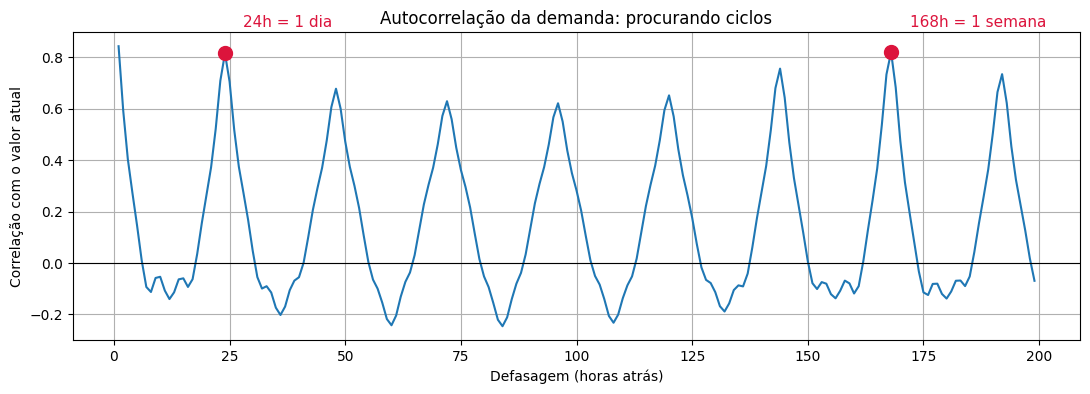

In [231]:
# Autocorrelação: o quanto a demanda de agora se parece com a de "k horas atrás"
defasagens = np.arange(1, 200)
autocorr = [df["count"].autocorr(k) for k in defasagens]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(defasagens, autocorr, lw=1.5)
ax.axhline(0, color="k", lw=0.8)
for k, rotulo in [(24, "24h = 1 dia"), (168, "168h = 1 semana")]:
    ax.plot(k, df["count"].autocorr(k), "o", color="crimson", markersize=10)
    ax.annotate(rotulo, (k, df["count"].autocorr(k)), xytext=(k + 4, 0.92), fontsize=11,
                color="crimson")
_ = ax.set(title="Autocorrelação da demanda: procurando ciclos",
           xlabel="Defasagem (horas atrás)", ylabel="Correlação com o valor atual")

### 🔎 Como ler o gráfico de autocorrelação

Este é o gráfico mais **investigativo** do EDA: ele **descobre** os ciclos, em vez de supô-los.

#### O que é autocorrelação, em uma frase

> É a correlação da série **com ela mesma, deslocada no tempo**.

`autocorr(24)` responde: *"o número de bicicletas de agora se parece com o de 24 horas atrás?"*

#### Não é magia — é a correlação de sempre

Para calcular `autocorr(24)`, o pandas monta duas colunas e correlaciona:

| índice | `count` agora | `count` 24h antes |
|--------|---------------|-------------------|
| 100 | 115 | 179 |
| 101 | 57 | 100 |
| 102 | 46 | 42 |
| 103 | 79 | 57 |

Depois aplica a **correlação de Pearson** entre elas. Nada além disso. A célula abaixo refaz essa
conta na mão e mostra que o resultado bate com `autocorr(24)`, usando os 17.355 pares
disponíveis (17.379 − 24, porque as 24 primeiras linhas não têm "24h antes").

#### Linha a linha do código

| Código | O que faz |
|--------|-----------|
| `defasagens = np.arange(1, 200)` | Vamos testar **todas** as defasagens de 1 a 199 horas — mais de 8 dias. |
| `[df["count"].autocorr(k) for k in defasagens]` | Uma correlação para cada defasagem: 199 números. |
| `ax.axhline(0)` | A linha de referência. **Zero = nenhuma semelhança.** |
| destaque em `24` e `168` | Marcamos os dois picos que interessam. |

#### Como ler o formato da curva, na ordem

1. **Começa alto** (+0,84 em 1h). Óbvio: a demanda de agora se parece com a de uma hora atrás.
   É **inércia**, não ciclo.
2. **Cai e cruza o zero perto de 6h** (+0,01). Seis horas depois, não há semelhança nenhuma.
3. **Fica NEGATIVA em torno de 12h** (−0,14). Este é o ponto mais importante do gráfico:
   meia volta do ciclo diário compara **madrugada com tarde**. Correlação negativa significa
   *"quando um está alto, o outro está baixo"*. **Correlação negativa é a assinatura de um ciclo** —
   ruído não faz isso.
4. **Volta ao máximo em 24h** (+0,82). Uma volta completa do relógio.
   👉 **ciclo diário confirmado**.
5. **E repete a onda** a cada 24 horas, indefinidamente.

#### 🕵️ O detalhe que o gráfico esconde: o segundo ciclo

Olhe só os picos diários, um a um (a célula abaixo imprime):

| Defasagem | 24h | 48h | 72h | **96h** | 120h | 144h | **168h** |
|-----------|-----|-----|-----|---------|------|------|----------|
| Autocorrelação | +0,82 | +0,68 | +0,63 | **+0,62** | +0,65 | +0,76 | **+0,82** |

A semelhança **cai até ~4 dias e depois volta a subir**, batendo no máximo de novo em **168h**.
Por quê?

> Porque 168h = 7 dias, e sete dias depois voltamos ao **mesmo dia da semana**.
> Uma quarta-feira se parece muito mais com a quarta anterior do que com o sábado que ficou no
> meio do caminho.

Isso é a assinatura do **ciclo semanal** — e é o motivo de `weekday` ser uma variável valiosa.

#### E se NÃO houvesse ciclo nenhum?

O gráfico seria uma linha rente ao zero. A célula abaixo gera um **ruído branco** para comparar:
autocorrelação de ~0,003 em qualquer defasagem. É esse contraste que dá sentido às ondas —
sem ele, não haveria como saber se +0,82 é muito ou pouco.

#### ⚠️ Duas ressalvas honestas

**1. A tendência infla a autocorrelação.** A série **não é estacionária** (§1.3): como 2012
inteiro está acima de 2011, qualquer par de horas dos "tempos altos" já se parece um pouco.
Parte da correlação positiva vem daí, e não de ciclo. Dá para testar: removendo o sinal lento
(a média móvel de §1.3),

- ACF(24h) quase não muda: +0,82 → +0,78
- ACF(168h) quase não muda: +0,82 → +0,80
- ACF(500h) **despenca**: +0,25 → +0,13

Ou seja: os **picos de 24h e 168h são estrutura cíclica real**; o "piso" positivo nas defasagens
longas é que era tendência disfarçada.

**2. A defasagem é em LINHAS, não em horas.** `autocorr(k)` desloca `k` **linhas** da tabela.
Como faltam 165 horas (§1.2), `k` linhas é *quase* `k` horas. Não muda as conclusões aqui, mas é
a mesma ressalva que faremos no baseline sazonal da FASE 2 (§2.4).

#### 🎯 Por que este gráfico justifica a aula inteira

A autocorrelação mostrou, **sem que ninguém precisasse supor nada**, que existem dois ciclos
fortes: **24h** e **168h**. É essa a justificativa empírica para tratar `hour` e `weekday` como
variáveis **cíclicas** — exatamente o que a FASE 3 vai fazer de quatro maneiras diferentes.

> Se esta curva fosse plana, a aula não teria objeto: não haveria ciclo para codificar.

In [232]:
# Os mesmos números, em tabela
print("Defasagem   Autocorrelação")
for k in [1, 3, 6, 12, 24, 48, 72, 168, 336]:
    print(f"  {k:>4}h        {df['count'].autocorr(k):+.3f}")

print()
print("--- 1) autocorr(k) é só a correlação de Pearson entre y[t] e y[t-k] ---")
par = pd.DataFrame({"agora": df["count"], "24h antes": df["count"].shift(24)}).dropna()
print("Pares disponíveis para k=24:", len(par), "( = 17379 - 24 )")
print("Correlação calculada na mão:", round(np.corrcoef(par["agora"], par["24h antes"])[0, 1], 4))
print("df['count'].autocorr(24)   :", round(df["count"].autocorr(24), 4))

print()
print("--- 2) múltiplos do DIA: a semelhança cai... e volta a subir ---")
for k in [24, 48, 72, 96, 120, 144, 168]:
    marca = ""
    if k == 96:
        marca = "   <- fundo: meio da semana"
    elif k == 168:
        marca = "   <- máximo: mesmo dia da semana"
    print(f"  {k:>4}h ({k // 24} dia(s)): {df['count'].autocorr(k):+.3f}{marca}")

print()
print("--- 3) contraste: como seria uma série SEM ciclo ---")
ruido = pd.Series(np.random.default_rng(0).normal(size=len(df)))
print("Ruído branco -> autocorr(1):", round(ruido.autocorr(1), 3),
      "| autocorr(24):", round(ruido.autocorr(24), 3))

print()
print("--- 4) quanto da autocorrelação é apenas TENDÊNCIA? ---")
sem_tendencia = (df["count"] - df["count"].rolling(24 * 14, center=True).mean()).dropna()
for k in [24, 168, 500]:
    print(f"  ACF({k:>3}h): série original {df['count'].autocorr(k):+.3f}"
          f"   |   sem o sinal lento {sem_tendencia.autocorr(k):+.3f}")

Defasagem   Autocorrelação
     1h        +0.844
     3h        +0.404
     6h        +0.010
    12h        -0.140
    24h        +0.816
    48h        +0.678
    72h        +0.630
   168h        +0.821
   336h        +0.765

--- 1) autocorr(k) é só a correlação de Pearson entre y[t] e y[t-k] ---
Pares disponíveis para k=24: 17355 ( = 17379 - 24 )
Correlação calculada na mão: 0.8158
df['count'].autocorr(24)   : 0.8158

--- 2) múltiplos do DIA: a semelhança cai... e volta a subir ---
    24h (1 dia(s)): +0.816
    48h (2 dia(s)): +0.678
    72h (3 dia(s)): +0.630
    96h (4 dia(s)): +0.622   <- fundo: meio da semana
   120h (5 dia(s)): +0.653
   144h (6 dia(s)): +0.757
   168h (7 dia(s)): +0.821   <- máximo: mesmo dia da semana

--- 3) contraste: como seria uma série SEM ciclo ---
Ruído branco -> autocorr(1): 0.003 | autocorr(24): 0.004

--- 4) quanto da autocorrelação é apenas TENDÊNCIA? ---
  ACF( 24h): série original +0.816   |   sem o sinal lento +0.782
  ACF(168h): série original +

### 📌 A autocorrelação **descobriu** os ciclos para nós

Repare no formato do gráfico: ele **oscila**, com picos regulares.

- **Defasagem 1h → +0,84.** Óbvio: a demanda de agora se parece com a de uma hora atrás.
- **Defasagem 12h → −0,14.** Meio dia depois, o padrão está *invertido* (madrugada × tarde).
- **Defasagem 24h → +0,82.** Um dia inteiro depois, a semelhança **volta ao máximo**.
  👉 existe um **ciclo diário**.
- **Defasagem 168h → +0,82.** Uma semana depois, semelhança máxima de novo — e note que 164h e
  172h (dois dos vizinhos) caem para ~0,2. O pico é **estreito e específico**.
  👉 existe um **ciclo semanal**.

Isso é evidência, não suposição: as colunas `hour` e `weekday` **contêm sinal forte** e são as
mais promissoras do dataset. Vamos olhar cada uma.

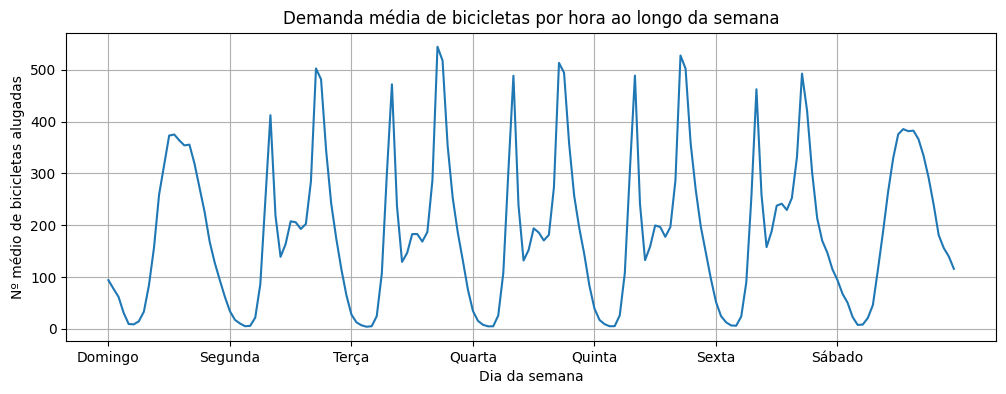

In [233]:
# Demanda média por hora ao longo da semana (7 dias x 24 horas = 168 pontos)
fig, ax = plt.subplots(figsize=(12, 4))
demanda_media_semana = df.groupby(["weekday", "hour"])["count"].mean()
demanda_media_semana.plot(ax=ax)
_ = ax.set(
    title="Demanda média de bicicletas por hora ao longo da semana",
    xticks=[i * 24 for i in range(7)],
    xticklabels=["Domingo", "Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado"],
    xlabel="Dia da semana",
    ylabel="Nº médio de bicicletas alugadas",
)

### 📌 Leitura do gráfico — guarde isto, vai ser importante

Dois padrões saltam aos olhos:

1. **Dias úteis (segunda a sexta)**: a curva tem **dois picos** — 8h e 18h.
   São as pessoas indo e voltando do trabalho.
2. **Fim de semana (sábado e domingo)**: a curva tem **um único pico**, largo, no meio da tarde.
   É o uso de lazer.

Ou seja: **o efeito da hora depende do dia da semana**. Isso se chama **interação** entre variáveis.
Guarde esse ponto — na FASE 4 (§4.1) ele explica a diferença entre um modelo linear e uma rede neural.

Repare também que a curva dos dias úteis é **pontiaguda** (sobe e desce rápido em torno das 8h).
Isso vai ser um argumento a favor dos *splines* na FASE 3 (§3.4).

Pico em dia útil        : 17 h -> 525 bicicletas
Pico em fim de semana   : 13 h -> 373 bicicletas
Correlação entre as duas curvas: 0.501


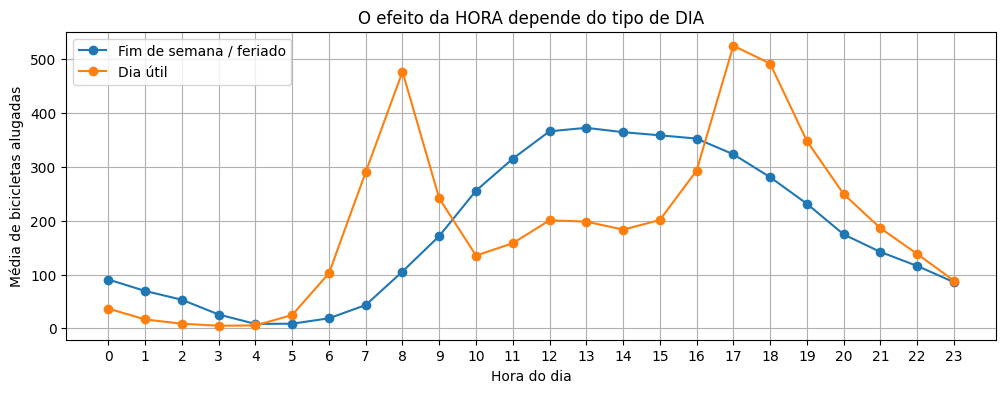

In [234]:
# A interação hora x dia útil, isolada em duas curvas
perfil = df.pivot_table(index="hour", columns="workingday", values="count",
                        aggfunc="mean", observed=True)
perfil.columns = ["Fim de semana / feriado", "Dia útil"]

fig, ax = plt.subplots(figsize=(12, 4))
perfil.plot(ax=ax, marker="o")
_ = ax.set(title="O efeito da HORA depende do tipo de DIA",
           xlabel="Hora do dia", ylabel="Média de bicicletas alugadas", xticks=range(0, 24))
_ = ax.legend(title="")

print("Pico em dia útil        :", perfil["Dia útil"].idxmax(), "h ->",
      round(perfil["Dia útil"].max()), "bicicletas")
print("Pico em fim de semana   :", perfil["Fim de semana / feriado"].idxmax(), "h ->",
      round(perfil["Fim de semana / feriado"].max()), "bicicletas")
print("Correlação entre as duas curvas:", round(perfil.corr().iloc[0, 1], 3))

### 📌 Achado central para a modelagem: **interação**

As duas curvas têm **formatos diferentes**, não apenas alturas diferentes:

- **Dia útil**: dois picos estreitos, às **8h** e às **17h–18h** (ida e volta do trabalho).
  Entre eles, um vale.
- **Fim de semana**: um único pico largo, por volta das **13h** (lazer).

A correlação entre as duas curvas é de apenas **0,50** — ou seja, saber a hora **não basta**:
é preciso saber a hora **e** o tipo de dia, em conjunto.

Isso se chama **interação entre variáveis**, e é uma informação valiosa:

> Um modelo que apenas **soma** o efeito da hora com o efeito do dia útil **não consegue**
> representar isso, porque ele aprende **um único formato de curva horária**.

Esse achado é exatamente o que a **FASE 4 (§4.1)** vai explorar para comparar um modelo linear
com a rede neural.

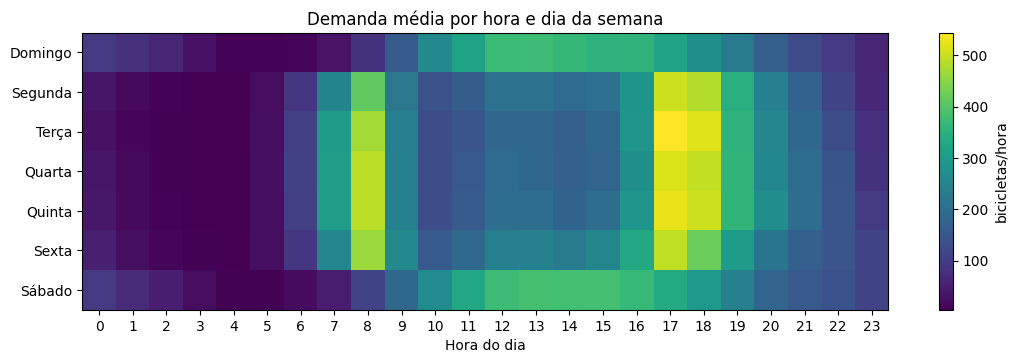

In [235]:
# Visão completa: mapa de calor hora x dia da semana
mapa = df.pivot_table(index="weekday", columns="hour", values="count",
                      aggfunc="mean", observed=True)

fig, ax = plt.subplots(figsize=(13, 3.6))
imagem = ax.imshow(mapa, aspect="auto", cmap="viridis")
ax.set(xticks=range(24), yticks=range(7),
       yticklabels=["Domingo", "Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado"],
       xlabel="Hora do dia", title="Demanda média por hora e dia da semana")
ax.grid(False)
_ = fig.colorbar(imagem, ax=ax, label="bicicletas/hora")

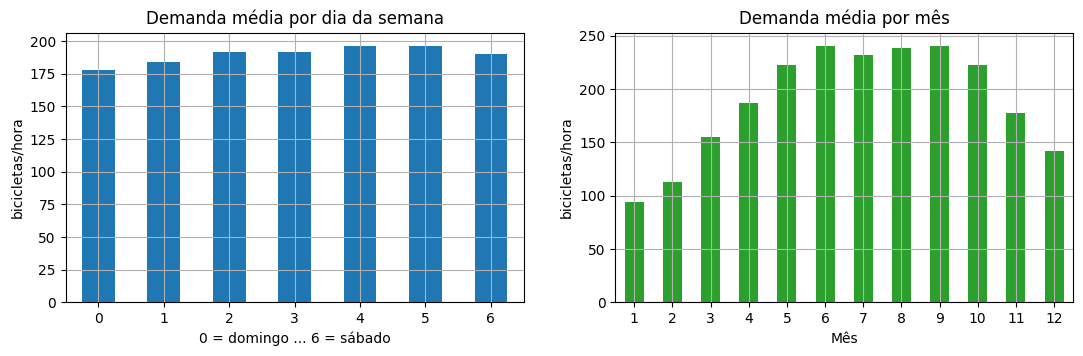

In [236]:
# Os outros dois ciclos: dia da semana e mês
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))

df.groupby("weekday")["count"].mean().plot(kind="bar", ax=ax1, color="tab:blue")
ax1.set(title="Demanda média por dia da semana", xlabel="0 = domingo ... 6 = sábado",
        ylabel="bicicletas/hora")
ax1.tick_params(axis="x", rotation=0)

df.groupby("month")["count"].mean().plot(kind="bar", ax=ax2, color="tab:green")
_ = ax2.set(title="Demanda média por mês", xlabel="Mês", ylabel="bicicletas/hora")
ax2.tick_params(axis="x", rotation=0)

### 📌 Síntese dos padrões temporais

| Ciclo | Evidência | Amplitude |
|-------|-----------|-----------|
| **Diário (24h)** | autocorrelação +0,82 em 24h; picos às 8h e 18h | a hora mais movimentada tem **~14×** a demanda da mais vazia |
| **Semanal (168h)** | autocorrelação +0,82 em 168h; formatos distintos em dia útil × fim de semana | moderada na média diária, **grande** no formato da curva |
| **Anual (12 meses)** | demanda sobe até setembro e despenca no inverno | **~3×** entre o melhor e o pior mês |

As três colunas de tempo — `hour`, `weekday`, `month` — carregam sinal.
**São elas o objeto de estudo da aula.** Antes de usá-las, porém, há uma peculiaridade
estrutural que precisa ser enfrentada.

---
## §1.5 — Achado estrutural: o tempo é **circular**

Em §1.1 notamos algo estranho: o `describe` calculou a *média* da hora do dia.
Aqui está o porquê de isso ser um sintoma.

In [237]:
# Distância entre horas do dia, do jeito que o modelo enxerga (número puro)
pares = [(23, 0), (23, 22), (0, 12)]

print("Como o MODELO enxerga (|h1 - h2|)      vs.   distância REAL no relógio")
print("-" * 70)
for h1, h2 in pares:
    dist_modelo = abs(h1 - h2)
    dist_real = min(abs(h1 - h2), 24 - abs(h1 - h2))
    print(f"{h1:>2}h e {h2:>2}h  ->  modelo: {dist_modelo:>2}   |   real: {dist_real:>2}"
          f"   {'  <-- ERRADO!' if dist_modelo != dist_real else ''}")

Como o MODELO enxerga (|h1 - h2|)      vs.   distância REAL no relógio
----------------------------------------------------------------------
23h e  0h  ->  modelo: 23   |   real:  1     <-- ERRADO!
23h e 22h  ->  modelo:  1   |   real:  1   
 0h e 12h  ->  modelo: 12   |   real: 12   


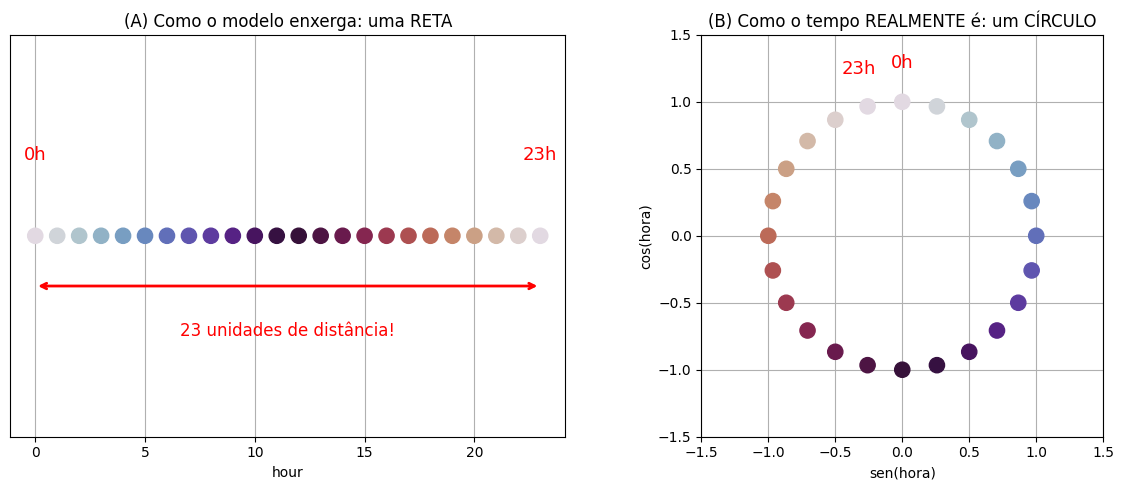

In [238]:
# A mesma ideia, visualmente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

horas = np.arange(24)

# (A) Como o modelo vê: uma reta
ax1.scatter(horas, np.zeros(24), c=horas, cmap="twilight", s=120, zorder=3)
for h in [0, 23]:
    ax1.annotate(f"{h}h", (h, 0), xytext=(h, 0.15), ha="center", fontsize=13, color="red")
ax1.annotate("", xy=(0, -0.1), xytext=(23, -0.1),
             arrowprops=dict(arrowstyle="<->", color="red", lw=2))
ax1.text(11.5, -0.2, "23 unidades de distância!", ha="center", color="red", fontsize=12)
ax1.set(title="(A) Como o modelo enxerga: uma RETA", xlabel="hour", ylim=(-0.4, 0.4), yticks=[])

# (B) Como o tempo realmente é: um círculo
ang = 2 * np.pi * horas / 24
ax2.scatter(np.sin(ang), np.cos(ang), c=horas, cmap="twilight", s=120, zorder=3)
for h in [0, 23]:
    ax2.annotate(f"{h}h", (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)),
                 xytext=(np.sin(2*np.pi*h/24)*1.25, np.cos(2*np.pi*h/24)*1.25),
                 ha="center", fontsize=13, color="red")
ax2.set(title="(B) Como o tempo REALMENTE é: um CÍRCULO",
        xlabel="sen(hora)", ylabel="cos(hora)", xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
ax2.set_aspect("equal")
plt.tight_layout()

### O diagnóstico

No gráfico (A), **0h e 23h são os pontos mais distantes do mundo** — mas na vida real
eles são vizinhos. A rede precisa "gastar" neurônios só para descobrir sozinha que a
extremidade direita da reta é igual à extremidade esquerda.

O mesmo vale para:
- `weekday`: sábado (6) e domingo (0) são vizinhos, mas o modelo os vê a 6 de distância;
- `month`: dezembro (12) e janeiro (1) são vizinhos, mas o modelo os vê a 11 de distância.

**Engenharia de atributos cíclicos** é justamente resolver isso na entrada,
em vez de esperar que a rede resolva sozinha.

---
## §1.6 — O clima ajuda a explicar a demanda?

O calendário explica *quando* as pessoas querem pedalar. O clima explica *se elas desistem*.

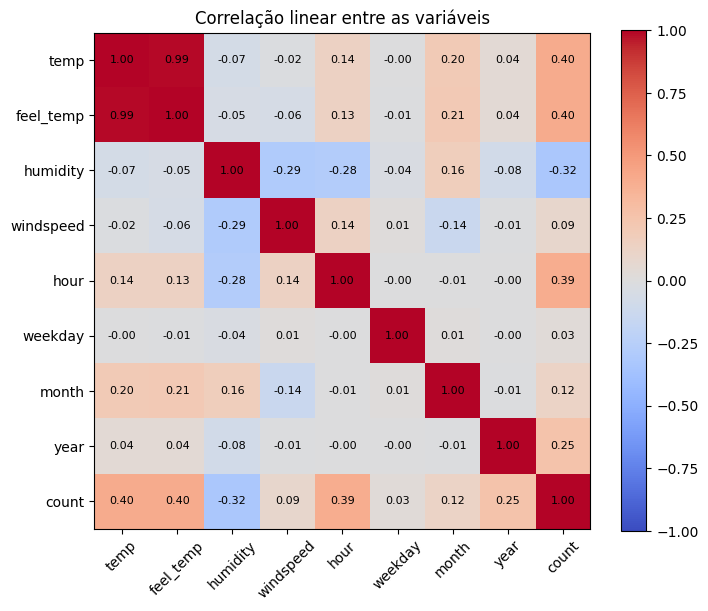

In [239]:
# Matriz de correlação entre as variáveis numéricas e o alvo
colunas_num = ["temp", "feel_temp", "humidity", "windspeed", "hour", "weekday", "month",
               "year", "count"]
correlacao = df[colunas_num].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
imagem = ax.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)
ax.set(xticks=range(len(colunas_num)), yticks=range(len(colunas_num)),
       xticklabels=colunas_num, yticklabels=colunas_num,
       title="Correlação linear entre as variáveis")
ax.tick_params(axis="x", rotation=45)
ax.grid(False)
for i in range(len(colunas_num)):
    for j in range(len(colunas_num)):
        ax.text(j, i, f"{correlacao.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
_ = fig.colorbar(imagem, ax=ax)

### 🔎 Como analisar uma matriz de correlação

#### O que cada quadradinho significa

Cada célula traz o **coeficiente de correlação de Pearson (r)** entre duas variáveis:
um número entre **−1 e +1**, sem unidade, que mede **o quanto os pontos se aproximam de uma
reta**.

| Valor de r | Leitura |
|------------|---------|
| **+1** | relação linear perfeita e crescente |
| **0** | nenhuma relação **linear** (pode haver outra!) |
| **−1** | relação linear perfeita e decrescente |

Três propriedades do gráfico que ajudam a se orientar:

- **A diagonal é sempre 1** — toda variável é perfeitamente correlacionada consigo mesma.
- **A matriz é simétrica**: o triângulo de cima é o espelho do de baixo. Metade da figura é
  redundante — analise só um lado.
- **A cor traduz o valor**: no `coolwarm`, **vermelho = positivo**, **azul = negativo**,
  **branco = perto de zero**. Fixamos `vmin=-1, vmax=1` justamente para que a mesma cor
  signifique sempre o mesmo valor.

#### Como analisar, em três varreduras

**Varredura 1 — a linha do alvo (`count`).** É a mais direta: quem se move junto com o que
queremos prever?

| Variável | r com `count` | Leitura |
|----------|---------------|---------|
| `temp` | **+0,405** | mais calor, mais bicicletas |
| `feel_temp` | +0,401 | idem (sensação térmica) |
| `hour` | +0,394 | ⚠️ leia a armadilha 1 antes de acreditar |
| `year` | +0,250 | a tendência de crescimento de §1.3 |
| `month` | +0,121 | sazonalidade, mal capturada por uma reta |
| `windspeed` | +0,093 | quase nada |
| `weekday` | +0,027 | ⚠️ leia a armadilha 2 |
| `humidity` | **−0,323** | **negativo**: mais umidade, menos bicicletas |

**Varredura 2 — os blocos entre as preditoras.** Aqui procuramos **redundância**: duas variáveis
que dizem a mesma coisa. É o caso gritante de **`temp` × `feel_temp` = 0,988**.

**Varredura 3 — a intensidade.** Nenhuma correlação com o alvo passa de 0,41. Em um dataset com
padrões tão fortes quanto os que vimos em §1.4, isso deveria soar como um **alerta**: a matriz
está enxergando pouco. E está mesmo — pelos motivos a seguir.

---

### ⚠️ As quatro armadilhas da matriz de correlação

#### Armadilha 1 — correlação só enxerga **reta**

`hour` aparece com apenas +0,39. Mas nós **já vimos** em §1.4 que a hora é a variável mais
informativa do dataset. Quem está errado?

A correlação. Ela pergunta *"os pontos formam uma reta?"* — e a demanda ao longo do dia
**sobe, desce e sobe de novo**. Nenhuma reta descreve isso.

A célula abaixo compara duas medidas:

- **r²** — quanto da variação do alvo uma **reta** sobre a variável explica;
- **η² (eta ao quadrado)** — quanto a variável explica **sem impor formato nenhum**
  (basta usar a média do alvo em cada valor dela).

| Variável | r² (reta) | η² (real) | Conclusão |
|----------|-----------|-----------|-----------|
| **`hour`** | **0,155** | **0,501** | a hora explica **50%** da variação, não 16% — **3,2× mais** do que a correlação sugere |
| `temp` | 0,164 | 0,176 | quase iguais → a relação **é** aproximadamente linear |

E o tamanho real do efeito da hora: a média vai de **6 bicicletas às 4h** a **461 às 17h** —
uma razão de **73×**.

> **Regra:** nunca descarte uma variável por causa de correlação baixa.
> Correlação baixa significa *"não é uma reta"*, não *"não serve"*.

#### Armadilha 2 — uma variável pode ser inútil sozinha e valiosa **em combinação**

Olhe `weekday`: r = **+0,027** e η² = **0,001**. Sozinha, ela não explica **nada** — a demanda
média de uma terça é parecida com a de um sábado.

Mas em §1.4 vimos que o dia da semana **muda completamente o formato da curva horária**
(dois picos × um pico). Como isso é possível?

> Porque a correlação mede o efeito **marginal** — o efeito da variável **na média**, ignorando
> as demais. Ela é **cega a interações**.

`weekday` não desloca a demanda para cima ou para baixo; ela **redistribui** a demanda ao longo
do dia. Na média do dia inteiro, isso se cancela.

Esta é a armadilha mais perigosa das três, porque leva a **descartar exatamente a variável que
dá o pulo de qualidade** — e é o assunto da FASE 4 (§4.1).

#### Armadilha 3 — a matriz **ignora** as variáveis categóricas

`season`, `weather`, `holiday` e `workingday` **não aparecem** no gráfico: `corr()` só trabalha
com números. **Ausência na matriz não é evidência de irrelevância** — `season`, por exemplo,
explica 6,6% da variação (a célula abaixo mostra).

#### Armadilha 4 — correlação não é causalidade

`year` tem r = +0,25, mas o ano de 2012 não *causa* demanda: o que cresceu foi a adoção do
serviço. E `month` se correlaciona com `temp` (+0,20) — as pessoas pedalam mais em setembro
porque está agradável, não porque o calendário manda.

---

### 📋 Achados desta seção

| Achado | Evidência | Consequência |
|--------|-----------|--------------|
| `temp` e `feel_temp` são redundantes | r = 0,988 | Manter as duas é inofensivo para a rede, mas descartar uma é razoável — vira exercício |
| A relação com a hora é **fortemente não linear** | r² 0,155 × η² 0,501 | Justifica um modelo não linear (a MLP) e a codificação cíclica da FASE 3 |
| `weekday` só tem valor **em interação** | η² = 0,001, mas muda o formato da curva (§1.4) | Justifica a comparação linear × rede neural da FASE 4 (§4.1) |
| A umidade tem efeito **inverso** | r = −0,323 | Variável útil, com sinal esperado |

In [240]:
# Correlação de cada variável com o alvo, em ordem
print("Correlação LINEAR com o alvo (count):")
print(correlacao["count"].drop("count").sort_values(ascending=False).round(3).to_string())
print()
print("Redundância -> correlação entre temp e feel_temp:",
      round(df["temp"].corr(df["feel_temp"]), 4))


# --- a armadilha 1, quantificada -----------------------------------------
def variacao_explicada(coluna):
    """eta²: fração da variação do alvo explicada por CONHECER o valor da coluna.

    Diferente do r², não impõe formato nenhum à relação: apenas usa a média
    do alvo dentro de cada valor da variável.
    """
    media_geral = df["count"].mean()
    soma_total = ((df["count"] - media_geral) ** 2).sum()
    soma_entre_grupos = df.groupby(coluna, observed=True)["count"].apply(
        lambda grupo: len(grupo) * (grupo.mean() - media_geral) ** 2).sum()
    return soma_entre_grupos / soma_total


print()
print("--- reta (r²) x relação real (eta²) ---")
print(f"{'variável':12s} {'r':>8s} {'r² (reta)':>11s} {'eta² (real)':>12s}")
for coluna in ["hour", "temp", "humidity", "weekday", "month"]:
    r = df[coluna].corr(df["count"])
    print(f"{coluna:12s} {r:+8.3f} {r ** 2:11.3f} {variacao_explicada(coluna):12.3f}")

media_por_hora = df.groupby("hour")["count"].mean()
print()
print(f"Efeito real da hora: média vai de {media_por_hora.min():.0f} bicicletas"
      f" (às {media_por_hora.idxmin()}h) a {media_por_hora.max():.0f}"
      f" (às {media_por_hora.idxmax()}h) -> razão de {media_por_hora.max() / media_por_hora.min():.0f}x")

# --- a armadilha 3: as categóricas, que ficaram fora da matriz ------------
print()
print("--- variáveis CATEGÓRICAS (ausentes da matriz) e o quanto explicam ---")
for coluna in ["season", "weather", "workingday", "holiday"]:
    print(f"  {coluna:12s} eta² = {variacao_explicada(coluna):.3f}")

Correlação LINEAR com o alvo (count):
temp         0.405
feel_temp    0.401
hour         0.394
year         0.250
month        0.121
windspeed    0.093
weekday      0.027
humidity    -0.323

Redundância -> correlação entre temp e feel_temp: 0.9877

--- reta (r²) x relação real (eta²) ---
variável            r   r² (reta)  eta² (real)
hour           +0.394       0.155        0.501
temp           +0.405       0.164        0.176
humidity       -0.323       0.104        0.128
weekday        +0.027       0.001        0.001
month          +0.121       0.015        0.075

Efeito real da hora: média vai de 6 bicicletas (às 4h) a 461 (às 17h) -> razão de 73x

--- variáveis CATEGÓRICAS (ausentes da matriz) e o quanto explicam ---
  season       eta² = 0.066
  weather      eta² = 0.021
  workingday   eta² = 0.001
  holiday      eta² = 0.001


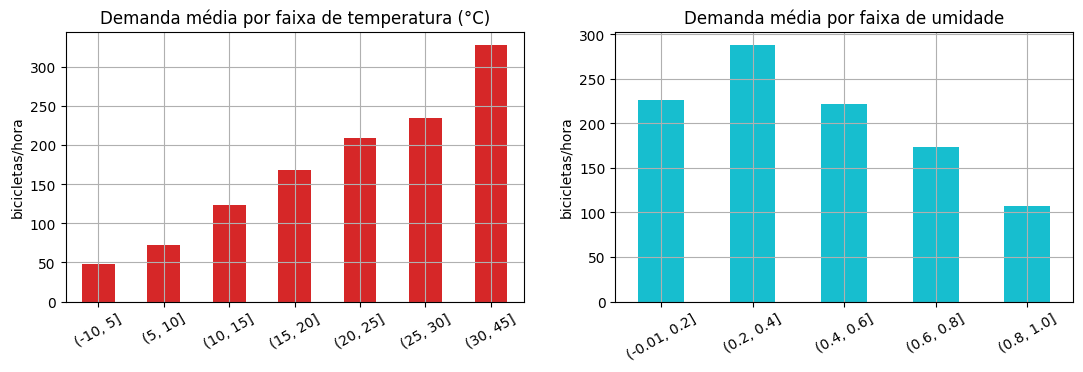

In [241]:
# A relação demanda x temperatura, em faixas (evita a armadilha da correlação linear)
faixas_temp = pd.cut(df["temp"], bins=[-10, 5, 10, 15, 20, 25, 30, 45])
faixas_umid = pd.cut(df["humidity"], bins=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
df.groupby(faixas_temp, observed=True)["count"].mean().plot(kind="bar", ax=ax1, color="tab:red")
ax1.set(title="Demanda média por faixa de temperatura (°C)", xlabel="", ylabel="bicicletas/hora")
ax1.tick_params(axis="x", rotation=30)

df.groupby(faixas_umid, observed=True)["count"].mean().plot(kind="bar", ax=ax2, color="tab:cyan")
_ = ax2.set(title="Demanda média por faixa de umidade", xlabel="", ylabel="bicicletas/hora")
ax2.tick_params(axis="x", rotation=30)

In [242]:
# E a condição do tempo (variável categórica)
print("Frequência de cada condição:")
print(df["weather"].value_counts().to_string())
print()
print("Demanda média em cada condição:")
print(df.groupby("weather", observed=True)["count"].mean().round(1).to_string())

Frequência de cada condição:
weather
clear         11413
misty          4544
rain           1419
heavy_rain        3

Demanda média em cada condição:
weather
clear         204.9
heavy_rain     74.3
misty         175.2
rain          111.6


### 📌 Achados do clima

- **Temperatura**: relação **monótona e forte** — de 49 bicicletas/hora no frio (< 5 °C) a 328 no
  calor (> 30 °C), quase **7×**. Variável valiosa.
- **Umidade**: relação **inversa** — acima de 80% de umidade a demanda cai pela metade.
  Faz sentido: umidade alta acompanha chuva.
- **Condição do tempo**: `clear` 205 → `misty` 175 → `rain` 112 bicicletas/hora. Coerente.
- ⚠️ **`heavy_rain` aparece em apenas 3 das 17.379 linhas.**
  Uma categoria com 3 exemplos é um problema prático sério: ela pode cair inteira no conjunto de
  teste e nunca aparecer no treino, quebrando o codificador. **Decisão para a FASE 2**:
  juntar `heavy_rain` com `rain`.

---
## §1.7 — Síntese do EDA: de achado para decisão

Esta é a entrega da FASE 1. Cada linha liga uma **evidência** a uma **decisão** — e é assim que
se justifica um projeto de modelagem.

| # | Achado (evidência) | Onde | Decisão que ele justifica | Onde é aplicada |
|---|--------------------|------|---------------------------|-----------------|
| 1 | Sem valores ausentes; duplicatas são falso positivo | §1.2 | Não imputar, não remover linhas | — |
| 2 | 165 horas ausentes (0,9%) | §1.2 | Atributos de defasagem são aproximados; usar com ressalva | §2.4 |
| 3 | Alvo assimétrico (*skew* +1,28), com cauda longa | §1.3 | Usar **MAE** como métrica principal (o RMSE seria dominado pelas horas de pico) | §2.3 |
| 4 | Alvo vai de 1 a 977, escala grande | §1.3 | **Normalizar** o alvo dividindo por 977 | §1.3 / §2.1 |
| 5 | Série **não estacionária** (2012 ≈ 2× 2011) | §1.3 | **Proibido embaralhar**: validação temporal com `TimeSeriesSplit` | §2.2 |
| 6 | Autocorrelação com picos em 24h e 168h | §1.4 | `hour` e `weekday` são as variáveis mais informativas | FASE 3 |
| 7 | Curva horária **muda de formato** conforme o dia útil | §1.4 | O modelo precisa capturar **interações** → favorece redes neurais | §4.1 |
| 8 | `hour`, `weekday` e `month` são **cíclicas** | §1.5 | Testar codificações cíclicas: one-hot, seno/cosseno, splines periódicos | **FASE 3 inteira** |
| 9 | `temp` e `feel_temp` com correlação 0,988 | §1.6 | Redundância registrada; descartar uma delas vira exercício | Exercícios |
| 10 | Relação demanda × hora é **não linear** | §1.6 | Não confiar só em correlação; usar modelo não linear | FASE 3 |
| 11 | `heavy_rain` com apenas 3 amostras | §1.6 | **Juntar** `heavy_rain` com `rain` | §2.1 |
| 12 | Escalas muito diferentes entre colunas | §1.1 | **Padronizar** as numéricas antes da rede | §3.1 |

### 🎯 A hipótese que sai do EDA

> Os achados **6, 7, 8 e 10** apontam todos para a mesma direção: o sinal mais forte do dataset
> está em variáveis **cíclicas**, com efeito **não linear** e com **interação** entre si.
>
> **Hipótese a testar:** apresentar essas variáveis à rede respeitando a sua natureza circular
> deve reduzir o erro de forma relevante — mesmo sem mudar nada na arquitetura da rede.
>
> É exatamente isso que a FASE 3 mede.

---
---

# 🛠️ FASE 2 — PREPARAÇÃO DOS DADOS E PROTOCOLO DE AVALIAÇÃO

Agora sim podemos **modificar** os dados — e cada modificação executa uma decisão tomada na
FASE 1, com o número do achado ao lado.

Esta fase entrega três coisas:

1. `X` e `y` prontos (§2.1)
2. Um **protocolo de validação** honesto para série temporal (§2.2)
3. **Métricas** e **baselines de referência**, para sabermos o que é um bom resultado (§2.3, §2.4)

## §2.1 — Matriz de atributos `X` e limpeza da `weather`  *(achado 11)*

In [243]:
X = df.drop("count", axis="columns")
X.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0


In [244]:
X["weather"].value_counts()

weather
clear         11413
misty          4544
rain           1419
heavy_rain        3
Name: count, dtype: int64

⚠️ A categoria `heavy_rain` aparece **pouquíssimas vezes**. Isso é um problema prático:

- Em validação cruzada, ela pode aparecer no **teste** e não no **treino**;
- o `OneHotEncoder` então encontra uma categoria desconhecida e quebra (ou a ignora, gerando ruído);
- e, com tão poucos exemplos, o modelo não aprenderia nada de útil sobre ela mesmo assim.

Solução simples e defensável: juntar `heavy_rain` com `rain`.

In [245]:
X["weather"] = (
    X["weather"]
    .astype(object)
    .replace(to_replace="heavy_rain", value="rain")
    .astype("category")
)

X["weather"].value_counts()

weather
clear    11413
misty     4544
rain      1422
Name: count, dtype: int64

---
## §2.2 — Validação cruzada em séries temporais  *(achado 5)*

### ❌ Por que NÃO podemos usar `KFold` embaralhado?

Com `shuffle=True`, o modelo treinaria com dados de **dezembro de 2012** para prever
**março de 2011**. Isso é **vazamento de dados (data leakage)**: ele "vê o futuro", e o erro
medido fica otimista demais — irreal.

### ✅ `TimeSeriesSplit`

Treina sempre no **passado** e testa no **futuro**, em janelas sucessivas:

```
Split 1: [==== treino ====] gap [teste]
Split 2:      [==== treino ====] gap [teste]
Split 3:           [==== treino ====] gap [teste]
...
```

Parâmetros que vamos usar:

| Parâmetro | Valor | Por quê |
|-----------|-------|---------|
| `n_splits=5` | 5 rodadas | média de 5 medições, mais confiável que uma só |
| `gap=48` | pula 48 horas | 2 dias entre treino e teste: evita "vazamento por vizinhança" (uma hora é quase idêntica à anterior) |
| `max_train_size=10000` | ~14 meses | janela de treino de tamanho fixo em todas as rodadas → comparação justa |
| `test_size=1000` | ~42 dias | tamanho fixo de teste |

In [246]:
from sklearn.model_selection import TimeSeriesSplit

ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,               # 48 horas de intervalo entre treino e teste
    max_train_size=10000, # janela de treino fixa
    test_size=1000,       # janela de teste fixa
)
ts_cv

TimeSeriesSplit(gap=48, max_train_size=10000, n_splits=5, test_size=1000)

In [247]:
# Materializamos os splits para inspecionar e reutilizar depois
todos_splits = list(ts_cv.split(X, y))

for i, (idx_treino, idx_teste) in enumerate(todos_splits):
    print(
        f"Split {i}: treino = indices {idx_treino[0]:>5} a {idx_treino[-1]:>5} "
        f"({len(idx_treino)} horas)  |  teste = {idx_teste[0]:>5} a {idx_teste[-1]:>5} "
        f"({len(idx_teste)} horas)"
    )

Split 0: treino = indices  2331 a 12330 (10000 horas)  |  teste = 12379 a 13378 (1000 horas)
Split 1: treino = indices  3331 a 13330 (10000 horas)  |  teste = 13379 a 14378 (1000 horas)
Split 2: treino = indices  4331 a 14330 (10000 horas)  |  teste = 14379 a 15378 (1000 horas)
Split 3: treino = indices  5331 a 15330 (10000 horas)  |  teste = 15379 a 16378 (1000 horas)
Split 4: treino = indices  6331 a 16330 (10000 horas)  |  teste = 16379 a 17378 (1000 horas)


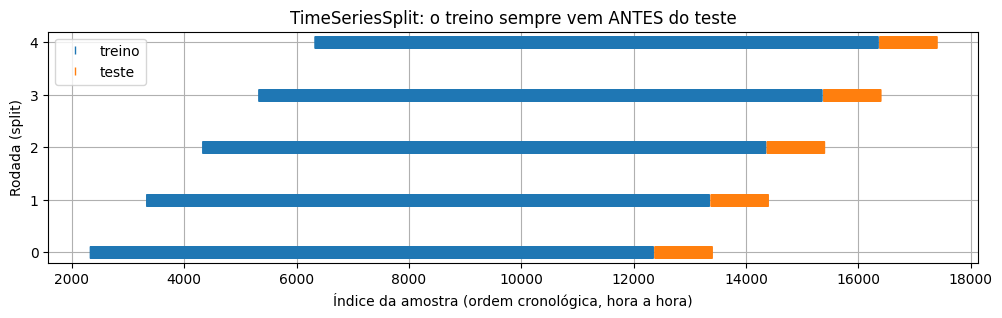

In [248]:
# Visualização dos splits: cada linha é uma rodada da validação cruzada
fig, ax = plt.subplots(figsize=(12, 3))
for i, (idx_treino, idx_teste) in enumerate(todos_splits):
    ax.plot(idx_treino, np.full_like(idx_treino, i), "|", color="tab:blue", markersize=8)
    ax.plot(idx_teste, np.full_like(idx_teste, i), "|", color="tab:orange", markersize=8)

ax.plot([], [], "|", color="tab:blue", label="treino")
ax.plot([], [], "|", color="tab:orange", label="teste")
_ = ax.set(
    title="TimeSeriesSplit: o treino sempre vem ANTES do teste",
    xlabel="Índice da amostra (ordem cronológica, hora a hora)",
    ylabel="Rodada (split)",
    yticks=range(len(todos_splits)),
)
_ = ax.legend(loc="upper left")

In [249]:
# Conferindo o gap de 48 horas no primeiro split
idx_treino_0, idx_teste_0 = todos_splits[0]

print("Últimas 3 horas do TREINO:")
print(X.iloc[idx_treino_0].tail(3)[["year", "month", "hour", "weekday"]])
print()
print("Primeiras 3 horas do TESTE:")
print(X.iloc[idx_teste_0].head(3)[["year", "month", "hour", "weekday"]])
print()
print("Horas puladas entre treino e teste (gap):", idx_teste_0[0] - idx_treino_0[-1] - 1)

Últimas 3 horas do TREINO:
       year  month  hour  weekday
12328     1      6    21        6
12329     1      6    22        6
12330     1      6    23        6

Primeiras 3 horas do TESTE:
       year  month  hour  weekday
12379     1      6     0        2
12380     1      6     1        2
12381     1      6     2        2

Horas puladas entre treino e teste (gap): 48


---
## §2.3 — Métricas e função padrão de avaliação  *(achado 3)*

Todos os modelos serão avaliados **exatamente do mesmo jeito**, com a mesma validação cruzada.
Só assim a comparação é honesta: a **única** coisa que muda entre os modelos é a
codificação do tempo.

Os resultados vão para um dicionário, para montarmos a tabela comparativa no final.

In [250]:
from sklearn.model_selection import cross_validate

# Guarda os resultados de todos os modelos da aula
resultados = {}


def avaliar(modelo, nome, verbose=True):
    """Roda a validação cruzada temporal e guarda MAE e RMSE.

    Observação: as métricas do scikit-learn seguem a convenção
    "quanto maior, melhor". Por isso o erro vem com sinal negativo
    (neg_mean_absolute_error) e precisamos inverter o sinal.
    """
    cv = cross_validate(
        modelo,
        X,
        y,
        cv=ts_cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_train_score=True,
    )

    mae_teste = -cv["test_neg_mean_absolute_error"]
    rmse_teste = -cv["test_neg_root_mean_squared_error"]
    mae_treino = -cv["train_neg_mean_absolute_error"]

    resultados[nome] = {
        "MAE": mae_teste.mean(),
        "desvio": mae_teste.std(),
        "RMSE": rmse_teste.mean(),
        "MAE treino": mae_treino.mean(),
        "erro em bicicletas": mae_teste.mean() * frota_max,
    }

    if verbose:
        print(f"===== {nome} =====")
        print(f"MAE  teste : {mae_teste.mean():.4f} +/- {mae_teste.std():.4f}"
              f"   (~{mae_teste.mean() * frota_max:.0f} bicicletas de erro por hora)")
        print(f"RMSE teste : {rmse_teste.mean():.4f} +/- {rmse_teste.std():.4f}")
        print(f"MAE treino : {mae_treino.mean():.4f}"
              f"   (gap treino->teste = {mae_teste.mean() - mae_treino.mean():+.4f})")
    return cv

### Como avalio o modelo? E por que escolhemos o MAE?

Esta é a pergunta mais importante da FASE 2. Vamos por partes.

#### 1. O protocolo: o que a função `avaliar()` faz, passo a passo

Para **cada uma das 5 rodadas** do `TimeSeriesSplit`, o `cross_validate` executa:

| Passo | O que acontece | Por que importa |
|-------|----------------|-----------------|
| 1 | Separa a janela de treino (10.000 horas) e a de teste (1.000 horas), pulando 48h | O teste é sempre **futuro** em relação ao treino (achado 5) |
| 2 | Ajusta o pré-processamento **só no treino** (média e desvio do `StandardScaler`, categorias do `OneHotEncoder`) | Se ajustasse no conjunto todo, informação do teste vazaria para o treino |
| 3 | Treina a rede **só no treino** | — |
| 4 | Prevê a janela de teste, que o modelo **nunca viu** | É a única medição honesta |
| 5 | Calcula MAE e RMSE nessa janela | — |

No fim, temos **5 medições independentes**. Reportamos **média ± desvio-padrão**:
a média estima o desempenho típico; o desvio mostra o quanto ele **varia conforme o período**.
Um modelo com MAE 0,05 ± 0,04 é bem menos confiável que um com 0,05 ± 0,003.

Também pedimos `return_train_score=True` para comparar treino e teste:
a diferença entre eles é a medida direta de **overfitting**.

#### 2. As duas métricas, na fórmula

Sendo $y_i$ o valor real e $\hat{y}_i$ a previsão, em $n$ horas de teste:

$$ \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
\qquad\qquad
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

A diferença é uma só: o **MAE soma o erro**, o **RMSE soma o erro ao quadrado**.
Parece um detalhe, mas muda completamente o que a métrica valoriza.

#### 3. Por que isso importa: dois modelos com o mesmo MAE

A célula abaixo constrói dois modelos hipotéticos para as mesmas 5 horas.
Rode e compare — os números falam sozinhos.

In [251]:
# Por que MAE e RMSE não medem a mesma coisa
real = np.array([100, 120, 90, 110, 500])
previsao_A = np.array([120, 100, 110, 90, 480])   # erra 20 em TODAS as horas
previsao_B = np.array([100, 120, 90, 110, 400])   # acerta 4 horas e erra 100 na hora de pico

print(f"{'':38s} {'erros':>22s} {'MAE':>7s} {'RMSE':>7s}")
for nome, previsao in [("A: erra pouco em todas as horas", previsao_A),
                       ("B: acerta 4 e erra feio no pico", previsao_B)]:
    erros = np.abs(real - previsao)
    mae = erros.mean()
    rmse = np.sqrt((erros ** 2).mean())
    print(f"{nome:38s} {str(erros.tolist()):>22s} {mae:7.1f} {rmse:7.1f}")

print()
print("Mesmo MAE (20), RMSE muito diferente (20 vs 44,7).")
print("Um erro de 100 pesa, em relação a um erro de 10:")
print(f"   no MAE : {100 / 10:.0f}x")
print(f"   no RMSE: {100 ** 2 / 10 ** 2:.0f}x   (porque entra ao quadrado)")

                                                        erros     MAE    RMSE
A: erra pouco em todas as horas          [20, 20, 20, 20, 20]    20.0    20.0
B: acerta 4 e erra feio no pico             [0, 0, 0, 0, 100]    20.0    44.7

Mesmo MAE (20), RMSE muito diferente (20 vs 44,7).
Um erro de 100 pesa, em relação a um erro de 10:
   no MAE : 10x
   no RMSE: 100x   (porque entra ao quadrado)


#### 4. A decisão: por que **MAE** como métrica principal

O exemplo acima mostra que o RMSE **pune desproporcionalmente os erros grandes**.
Agora junte isso ao achado 3 da FASE 1:

- o alvo é **assimétrico**, com **8% das horas** concentrando a demanda alta;
- essas horas de pico são justamente as **mais difíceis** de prever.

Se usássemos o RMSE como métrica principal, **essas 8% de horas dominariam a avaliação**: a
comparação entre as codificações de tempo — que é o objetivo da aula — seria decidida por um
punhado de horas extremas, e não pelo comportamento geral do modelo. Com o MAE, **cada hora pesa
igual**.

Somam-se dois motivos práticos:

- **Interpretabilidade**: MAE = "erro médio em bicicletas por hora". Basta multiplicar por 977.
  O RMSE não tem leitura direta (é uma média quadrática).
- **Robustez**: uma única hora anômala (falha de sensor, evento na cidade) desloca pouco o MAE e
  muito o RMSE.

#### 5. Então por que ainda reportamos o RMSE?

Porque a **comparação entre as duas** é um diagnóstico:

| Situação | O que significa |
|----------|-----------------|
| RMSE ≈ MAE | Os erros são parecidos entre si; o modelo erra de forma uniforme |
| RMSE **muito maior** que MAE | Há **poucas horas com erro enorme** — tipicamente os picos |

Vamos ver esse segundo caso acontecer nos nossos modelos, e a FASE 4 mostra **quais** horas são.

> **Resumo:** MAE decide, RMSE diagnostica, o gap treino-teste denuncia overfitting.

---
## §2.4 — Baselines: a partir de que ponto um modelo "presta"?

Um MAE de 0,05 é bom? **Não dá para saber sem uma referência.** Por isso, antes de treinar
qualquer rede, medimos dois modelos propositalmente burros — **sob exatamente o mesmo
protocolo** (mesma `ts_cv`, mesma função `avaliar`).

1. **Constante**: prever sempre a mediana do treino. Ignora todas as variáveis.
2. **Ingênuo sazonal**: prever "o que aconteceu nesta mesma hora, uma semana atrás".
   Usa o ciclo de 168h que a autocorrelação revelou em §1.4, sem aprender nada.

In [252]:
from sklearn.dummy import DummyRegressor

# Baseline 1: prever sempre um valor constante (a mediana da janela de treino)
_ = avaliar(DummyRegressor(strategy="median"), "0a. Baseline constante (mediana)")

===== 0a. Baseline constante (mediana) =====
MAE  teste : 0.1864 +/- 0.0285   (~182 bicicletas de erro por hora)
RMSE teste : 0.2440 +/- 0.0410
MAE treino : 0.1442   (gap treino->teste = +0.0421)


In [253]:
# Baseline 2: ingênuo sazonal - "a mesma hora, 7 dias atrás" (defasagem de 168 linhas)
# Ressalva do achado 2: como faltam 165 horas, "168 linhas atrás" é uma APROXIMAÇÃO de 1 semana.
mae_folds, rmse_folds = [], []
for idx_treino, idx_teste in todos_splits:
    previsto = y.shift(168).iloc[idx_teste].to_numpy()
    observado = y.iloc[idx_teste].to_numpy()
    valido = ~np.isnan(previsto)
    erro = np.abs(observado[valido] - previsto[valido])
    mae_folds.append(erro.mean())
    rmse_folds.append(np.sqrt((erro ** 2).mean()))

mae_folds, rmse_folds = np.array(mae_folds), np.array(rmse_folds)
resultados["0b. Ingênuo sazonal (t - 168h)"] = {
    "MAE": mae_folds.mean(),
    "desvio": mae_folds.std(),
    "RMSE": rmse_folds.mean(),
    "MAE treino": np.nan,          # não há treino: o modelo não aprende nada
    "erro em bicicletas": mae_folds.mean() * frota_max,
}

print("===== 0b. Ingênuo sazonal (t - 168h) =====")
print(f"MAE  teste : {mae_folds.mean():.4f} +/- {mae_folds.std():.4f}"
      f"   (~{mae_folds.mean() * frota_max:.0f} bicicletas de erro por hora)")
print(f"RMSE teste : {rmse_folds.mean():.4f}")

===== 0b. Ingênuo sazonal (t - 168h) =====
MAE  teste : 0.0729 +/- 0.0218   (~71 bicicletas de erro por hora)
RMSE teste : 0.1234


### 📌 Os dois sarrafos — e uma lição sobre honestidade na medição

| Referência | MAE | Em bicicletas | O que ela usa |
|------------|-----|---------------|---------------|
| Constante (mediana) | ~0,186 | **~182** | nada |
| Ingênuo sazonal (t−168h) | ~0,073 | **~71** | só o ciclo semanal |

**Qualquer modelo nosso precisa ficar bem abaixo de 182**, e um modelo que se pretenda útil
precisa **bater os ~71** do ingênuo sazonal — que não aprende absolutamente nada.

#### Por que 182 e não os ~138 de §1.3?

Lembra que em §1.3 a dispersão do alvo deu ~138 bicicletas, e avisamos que aquilo **não era** o
desempenho de um modelo? Aqui está a prova, e a diferença tem duas causas:

1. **Dentro × fora da amostra.** Em §1.3 a mediana foi calculada com os mesmos dados em que
   medimos o erro. Aqui ela é calculada **só no treino** e aplicada a um período **futuro**.
2. **A série não é estacionária** (achado 5). O `DummyRegressor` aprende a mediana do passado e a
   aplica a um futuro em que a demanda **cresceu**. Ele erra sistematicamente **para baixo**.

> 🔎 **A confirmação está nos próprios números.** Olhe o `MAE treino` do baseline constante
> impresso acima: **0,1442** (~141 bicicletas). É praticamente o valor que calculamos em §1.3
> (~138) — porque o escore de *treino* é exatamente uma medição **dentro** da amostra.
> O que leva de ~141 para ~182 é uma única mudança: **passar a medir no futuro**.

> **A lição:** medir dentro da amostra dá números **otimistas**. É exatamente por isso que o
> protocolo do §2.3 existe — e por que nenhum número de fase anterior pode ser comparado com os
> das FASES 3 e 4 sem passar pelo mesmo protocolo.

---
---

# 🧪 FASE 3 — MODELAGEM: quanto vale codificar o tempo corretamente?

Aqui testamos a hipótese que fechou a FASE 1.

**O experimento é controlado:** a rede é **sempre a mesma** (`criar_mlp()`), os dados são os
mesmos, a validação é a mesma. **A única coisa que muda é como `hour`, `weekday` e `month`
chegam à rede.** Assim, qualquer diferença de erro só pode ser atribuída à codificação.

| Modelo | Codificação do tempo | Ideia |
|--------|----------------------|-------|
| 1 | número puro, padronizado | o jeito ingênuo — nosso ponto de partida |
| 2 | one-hot | cada hora é uma categoria isolada |
| 3 | seno e cosseno | as horas em um círculo |
| 4 | splines periódicos | funções de base locais que fecham o ciclo |

---
## §3.1 — Modelo 1: baseline ingênuo (`hour` como número)

Nossa primeira tentativa é a mais direta possível:

- variáveis **numéricas** (incluindo `hour`, `weekday`, `month`) → `StandardScaler`
- variáveis **categóricas** (`season`, `holiday`, `workingday`, `weather`) → `OneHotEncoder`

O `StandardScaler` é obrigatório para redes neurais: sem ele, uma variável de escala grande
domina os gradientes e a rede demora muito (ou não consegue) convergir.

In [254]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separando os tipos de coluna
colunas_categoricas = ["season", "holiday", "workingday", "weather"]
colunas_ciclicas = ["hour", "weekday", "month"]          # o foco da aula
colunas_numericas = ["temp", "feel_temp", "humidity", "windspeed", "year"]

print("Categóricas:", colunas_categoricas)
print("Cíclicas   :", colunas_ciclicas)
print("Numéricas  :", colunas_numericas)

Categóricas: ['season', 'holiday', 'workingday', 'weather']
Cíclicas   : ['hour', 'weekday', 'month']
Numéricas  : ['temp', 'feel_temp', 'humidity', 'windspeed', 'year']


In [255]:
# MODELO 1: as colunas cíclicas entram como números puros, apenas padronizados
preproc_baseline = ColumnTransformer(
    transformers=[
        # hour, weekday e month entram junto com as numéricas comuns
        ("num", StandardScaler(), colunas_numericas + colunas_ciclicas),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False,
                              handle_unknown="ignore"), colunas_categoricas),
    ]
)
preproc_baseline

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['temp', 'feel_temp', 'humidity', 'windspeed',
                                  'year', 'hour', 'weekday', 'month']),
                                ('cat',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['season', 'holiday', 'workingday',
                                  'weather'])])

### A rede neural

Vamos usar sempre **a mesma arquitetura** em todos os modelos — a função `criar_mlp()`
devolve uma rede nova a cada chamada, para que nenhum modelo herde os pesos de outro.

| Hiperparâmetro | Valor | Papel |
|----------------|-------|-------|
| `hidden_layer_sizes=(32, 16)` | 2 camadas ocultas | capacidade de aprender combinações não lineares |
| `activation="relu"` | ReLU | não linearidade padrão, rápida e sem saturação |
| `solver="adam"` | Adam | otimizador robusto para bases médias/grandes |
| `learning_rate="adaptive"` | adaptativa | reduz o passo quando o erro para de cair |
| `early_stopping=True` | parada antecipada | separa 10% do treino para validação e para quando não melhora — **regularização** |
| `n_iter_no_change=15` | paciência | quantas épocas sem melhora antes de parar |
| `random_state=42` | semente | reprodutibilidade: todo mundo na sala vê o mesmo número |

In [256]:
from sklearn.neural_network import MLPRegressor


def criar_mlp():
    """Devolve sempre uma MLP nova, com os mesmos hiperparâmetros."""
    return MLPRegressor(
        hidden_layer_sizes=(32, 16),  # 2 camadas ocultas: 32 e 16 neurônios
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
    )


criar_mlp()

MLPRegressor(early_stopping=True, hidden_layer_sizes=(32, 16),
             learning_rate='adaptive', max_iter=300, n_iter_no_change=15,
             random_state=42)

In [257]:
from sklearn.pipeline import make_pipeline

# Pipeline = pré-processamento + rede neural, em um único objeto.
# Vantagem crucial: dentro da validação cruzada, o StandardScaler e o OneHotEncoder
# são ajustados SÓ com os dados de treino de cada rodada -> sem vazamento.
modelo_baseline = make_pipeline(preproc_baseline, criar_mlp())
modelo_baseline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['temp', 'feel_temp',
                                                   'humidity', 'windspeed',
                                                   'year', 'hour', 'weekday',
                                                   'month']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['season', 'holiday',
                                                   'workingday',
                                                   'weather'])])),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(32, 16),
                              learning_rate='adaptive', max_iter=300,
                              n_iter_no_change=15, random_state=42))])

In [258]:
%%time
cv_baseline = avaliar(modelo_baseline, "1. Baseline (hora como número)")

===== 1. Baseline (hora como número) =====
MAE  teste : 0.0647 +/- 0.0028   (~63 bicicletas de erro por hora)
RMSE teste : 0.0935 +/- 0.0042
MAE treino : 0.0315   (gap treino->teste = +0.0332)
CPU times: total: 14.2 s
Wall time: 14.7 s


### 🎯 Guarde esse número

Esse é o nosso **ponto de partida**. Tudo que fizermos a partir daqui tem que ser
comparado com ele. Nas próximas seções, **a única coisa que vai mudar é a forma de
codificar `hour`, `weekday` e `month`** — a rede, os dados e a validação continuam idênticos.

---
## §3.2 — Modelo 2: tempo como categorias (one-hot)

Primeira tentativa de conserto: tratar cada hora como uma **categoria** independente.
`hour=8` vira uma coluna 0/1, `hour=9` vira outra, e assim por diante.

- ✅ Elimina a falsa ordem: 23h não é mais "23 vezes mais" que 1h.
- ✅ Permite que cada hora tenha o seu próprio efeito, sem nenhuma suavidade imposta.
- ❌ **Perde a noção de vizinhança**: para o modelo, 8h e 9h agora são tão diferentes
  entre si quanto 8h e 3h. Ele não consegue "aproveitar" o que aprendeu de uma hora na hora seguinte.
- ❌ Gera muitas colunas: 24 + 7 + 12 = **43 colunas** só de tempo.

In [259]:
preproc_categorico = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False,
                              handle_unknown="ignore"), colunas_categoricas),
        # AQUI a mudança: hora/dia/mês viram one-hot
        ("tempo", OneHotEncoder(sparse_output=False,
                                handle_unknown="ignore"), colunas_ciclicas),
    ]
)

# Espiando o resultado da transformação
preproc_categorico.fit(X)
nomes = preproc_categorico.get_feature_names_out()
colunas_de_tempo = [n for n in nomes if n.startswith("tempo__")]

print("Nº total de colunas geradas:", len(nomes))
print("Só de tempo:", len(colunas_de_tempo), "colunas (24 horas + 7 dias + 12 meses)")
print("Exemplos:", colunas_de_tempo[:6], "...")

Nº total de colunas geradas: 57
Só de tempo: 43 colunas (24 horas + 7 dias + 12 meses)
Exemplos: ['tempo__hour_0', 'tempo__hour_1', 'tempo__hour_2', 'tempo__hour_3', 'tempo__hour_4', 'tempo__hour_5'] ...


In [260]:
%%time
modelo_categorico = make_pipeline(preproc_categorico, criar_mlp())
cv_categorico = avaliar(modelo_categorico, "2. Tempo como categorias (one-hot)")

===== 2. Tempo como categorias (one-hot) =====
MAE  teste : 0.0608 +/- 0.0089   (~59 bicicletas de erro por hora)
RMSE teste : 0.0846 +/- 0.0084
MAE treino : 0.0244   (gap treino->teste = +0.0364)
CPU times: total: 11.3 s
Wall time: 11.4 s


---
## §3.3 — Modelo 3: seno e cosseno (atributos trigonométricos)

### A ideia

Em vez de uma reta, colocamos as horas **em cima de um círculo**. Cada hora vira um
**par de coordenadas**:

$$ \text{hour\_sin} = \sin\left(\frac{2\pi \cdot h}{24}\right)
\qquad
\text{hour\_cos} = \cos\left(\frac{2\pi \cdot h}{24}\right) $$

Assim, 23h e 0h ficam **fisicamente próximos** no espaço de entrada — que é exatamente
o que a rede precisa saber.

> **Por que precisa de DOIS atributos (seno E cosseno)?**
> Com só o seno, 6h e 18h teriam o mesmo valor (sen = 1 e sen = −1... na verdade
> 3h e 9h teriam ambos valores parecidos e a curva se repetiria dentro do mesmo dia).
> O par (sen, cos) identifica **um único ponto** do círculo, sem ambiguidade.

In [261]:
from sklearn.preprocessing import FunctionTransformer


def sin_transformer(period):
    """Transforma uma coluna 0..period-1 no seno do ângulo correspondente."""
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))


def cos_transformer(period):
    """Transforma uma coluna 0..period-1 no cosseno do ângulo correspondente."""
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

In [262]:
# Como fica a codificação, hora a hora
horas_df = pd.DataFrame({"hour": np.arange(24)})
demo = pd.DataFrame({
    "hour": horas_df["hour"],
    "hour_sin": sin_transformer(24).fit_transform(horas_df)["hour"],
    "hour_cos": cos_transformer(24).fit_transform(horas_df)["hour"],
}).round(3)
demo.head(26)

,hour,hour_sin,hour_cos
0,0,0.000,1.000
1,1,0.259,0.966
2,2,0.500,0.866
3,3,0.707,0.707
4,4,0.866,0.500
5,5,0.966,0.259
6,6,1.000,0.000
7,7,0.966,-0.259
8,8,0.866,-0.500
9,9,0.707,-0.707


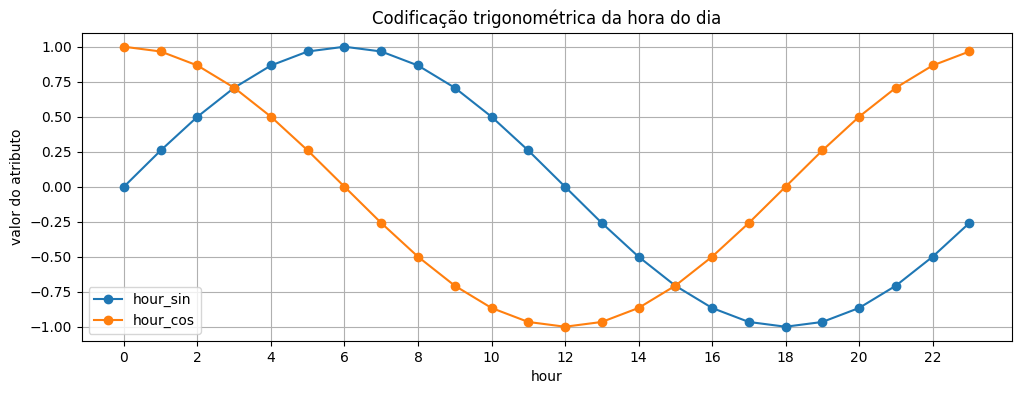

In [263]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(demo["hour"], demo["hour_sin"], "o-", label="hour_sin")
ax.plot(demo["hour"], demo["hour_cos"], "o-", label="hour_cos")
_ = ax.set(title="Codificação trigonométrica da hora do dia",
           xlabel="hour", ylabel="valor do atributo", xticks=range(0, 24, 2))
_ = ax.legend()

In [264]:
# Prova de que o problema do 23h/0h foi resolvido
def dist_trig(h1, h2):
    a1, a2 = 2 * np.pi * h1 / 24, 2 * np.pi * h2 / 24
    return np.hypot(np.sin(a1) - np.sin(a2), np.cos(a1) - np.cos(a2))

print("Distância no espaço (sen, cos):")
for h1, h2 in [(23, 0), (23, 22), (0, 12)]:
    print(f"  {h1:>2}h e {h2:>2}h  ->  {dist_trig(h1, h2):.3f}")
print()
print("23h/0h e 23h/22h agora têm a MESMA distância. O círculo fechou. ✅")

Distância no espaço (sen, cos):
  23h e  0h  ->  0.261
  23h e 22h  ->  0.261
   0h e 12h  ->  2.000

23h/0h e 23h/22h agora têm a MESMA distância. O círculo fechou. ✅


In [265]:
preproc_trigonometrico = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False,
                              handle_unknown="ignore"), colunas_categoricas),
        # Cada coluna cíclica vira um par (seno, cosseno) com o seu próprio período
        ("hora_sin",    sin_transformer(24), ["hour"]),
        ("hora_cos",    cos_transformer(24), ["hour"]),
        ("diasem_sin",  sin_transformer(7),  ["weekday"]),
        ("diasem_cos",  cos_transformer(7),  ["weekday"]),
        ("mes_sin",     sin_transformer(12), ["month"]),
        ("mes_cos",     cos_transformer(12), ["month"]),
    ]
)

print("Nº de colunas geradas:", preproc_trigonometrico.fit_transform(X).shape[1])
print("(2 colunas para cada um dos 3 ciclos, em vez de 43)")

Nº de colunas geradas: 20
(2 colunas para cada um dos 3 ciclos, em vez de 43)


In [266]:
%%time
modelo_trigonometrico = make_pipeline(preproc_trigonometrico, criar_mlp())
cv_trigonometrico = avaliar(modelo_trigonometrico, "3. Seno e cosseno")

===== 3. Seno e cosseno =====
MAE  teste : 0.0513 +/- 0.0027   (~50 bicicletas de erro por hora)
RMSE teste : 0.0747 +/- 0.0045
MAE treino : 0.0270   (gap treino->teste = +0.0243)
CPU times: total: 15.6 s
Wall time: 15.8 s


### ⚠️ A limitação do seno/cosseno

Seno e cosseno são curvas **suaves e com um único pico por período**.
Mas a demanda de bicicletas em dia útil tem **dois picos** (8h e 18h) e é **pontiaguda**.

Uma rede neural profunda o suficiente consegue construir esse formato a partir de
sen/cos — mas ela precisa "trabalhar" para isso. A alternativa da próxima seção entrega
esse formato de bandeja.

---
## §3.4 — Modelo 4: splines periódicos

### A ideia

Em vez de 2 curvas suaves cobrindo o dia inteiro, criamos **várias funções de base
localizadas**: cada uma "acende" em uma faixa de horas e é zero no resto.

É um meio-termo entre os dois extremos anteriores:

| | one-hot | splines periódicos | sen/cos |
|---|---|---|---|
| localização | total (cada hora isolada) | **parcial (faixas que se sobrepõem)** | nenhuma (global) |
| vizinhança preservada? | ❌ | **✅** | ✅ |
| fecha o círculo? | (não se aplica) | **✅ com `extrapolation="periodic"`** | ✅ |
| flexibilidade | máxima | **alta** | baixa (1 harmônico) |

O ingrediente mágico é `extrapolation="periodic"`: ele faz a última spline "dar a volta"
e reencontrar a primeira, garantindo que 23h e 0h sejam contínuos.

In [267]:
from sklearn.preprocessing import SplineTransformer


def periodic_spline_transformer(period, n_splines=None, degree=3):
    """Cria splines periódicos para uma variável cíclica.

    period    : tamanho do ciclo (24 horas, 7 dias, 12 meses)
    n_splines : quantas funções de base gerar (mais = mais flexível)
    degree    : grau do polinômio de cada pedaço (3 = cúbico, padrão)
    """
    if n_splines is None:
        n_splines = period
    n_knots = n_splines + 1  # o período fecha o círculo: 1º nó == último nó
    return SplineTransformer(
        degree=degree,
        n_knots=n_knots,
        knots=np.linspace(0, period, n_knots).reshape(n_knots, 1),
        extrapolation="periodic",  # <-- o segredo: fecha o ciclo
        include_bias=True,
    )

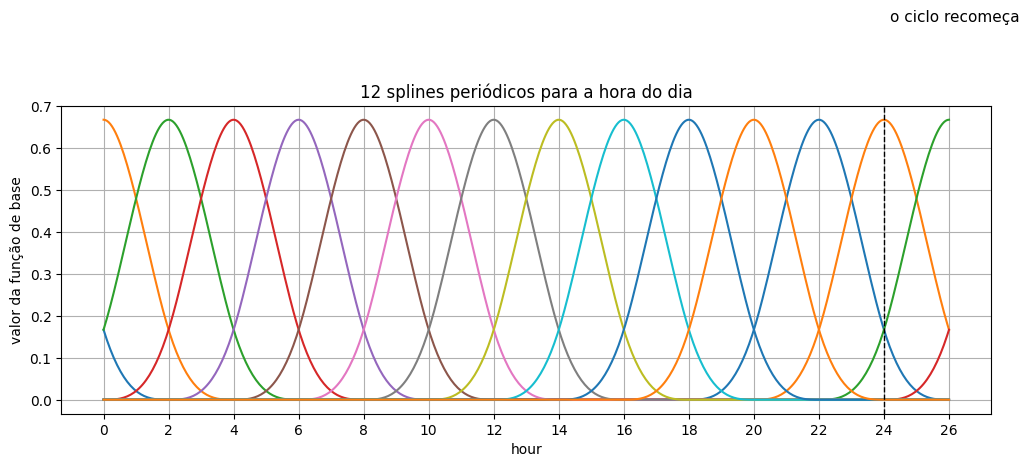

In [268]:
# Visualizando as 12 funções de base geradas para a hora do dia.
# Repare que o eixo x vai até 26 (mais de um dia) para mostrar que as curvas SE REPETEM.
horas_finas = pd.DataFrame(np.linspace(0, 26, 500).reshape(-1, 1), columns=["hour"])
base_splines = periodic_spline_transformer(24, n_splines=12).fit_transform(horas_finas)

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(base_splines.shape[1]):
    ax.plot(horas_finas["hour"], base_splines[:, i])
ax.axvline(24, color="k", ls="--", lw=1)
ax.text(24.2, 0.9, "o ciclo recomeça", fontsize=11)
_ = ax.set(title="12 splines periódicos para a hora do dia",
           xlabel="hour", ylabel="valor da função de base", xticks=range(0, 27, 2))

Cada curva é uma "janela" de algumas horas. Para uma hora específica — digamos 8h —
apenas 3 ou 4 splines têm valor diferente de zero. A rede recebe, portanto,
uma **descrição local e suave** de onde estamos no dia.

Escolha do `n_splines`:
- `hour` → 12 splines (uma "janela" a cada ~2 horas);
- `weekday` → 3 splines (só 7 valores possíveis, não adianta exagerar);
- `month` → 6 splines (uma janela a cada ~2 meses; a sazonalidade é lenta).

In [269]:
preproc_splines = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False,
                              handle_unknown="ignore"), colunas_categoricas),
        ("hora",    periodic_spline_transformer(24, n_splines=12), ["hour"]),
        ("diasem",  periodic_spline_transformer(7,  n_splines=3),  ["weekday"]),
        ("mes",     periodic_spline_transformer(12, n_splines=6),  ["month"]),
    ]
)

print("Nº de colunas geradas:", preproc_splines.fit_transform(X).shape[1])
print("(12 + 3 + 6 = 21 colunas de tempo)")

Nº de colunas geradas: 35
(12 + 3 + 6 = 21 colunas de tempo)


In [270]:
%%time
modelo_splines = make_pipeline(preproc_splines, criar_mlp())
cv_splines = avaliar(modelo_splines, "4. Splines periódicos")

===== 4. Splines periódicos =====
MAE  teste : 0.0539 +/- 0.0085   (~53 bicicletas de erro por hora)
RMSE teste : 0.0765 +/- 0.0092
MAE treino : 0.0252   (gap treino->teste = +0.0287)
CPU times: total: 11.5 s
Wall time: 11.8 s


---
## §3.5 — Comparação dos modelos

Hora de colocar tudo lado a lado. Lembre: **a rede é a mesma nos 4 casos**.
A única diferença é como o tempo foi apresentado a ela.

In [271]:
tabela = pd.DataFrame(resultados).T.sort_values("MAE")
tabela.round(4)

,MAE,desvio,RMSE,MAE treino,erro em bicicletas
3. Seno e cosseno,0.0513,0.0027,0.0747,0.0270,50.0856
4. Splines periódicos,0.0539,0.0085,0.0765,0.0252,52.7061
2. Tempo como categorias (one-hot),0.0608,0.0089,0.0846,0.0244,59.3612
1. Baseline (hora como número),0.0647,0.0028,0.0935,0.0315,63.2110
0b. Ingênuo sazonal (t - 168h),0.0729,0.0218,0.1234,NaN,71.1800
0a. Baseline constante (mediana),0.1864,0.0285,0.2440,0.1442,182.0786


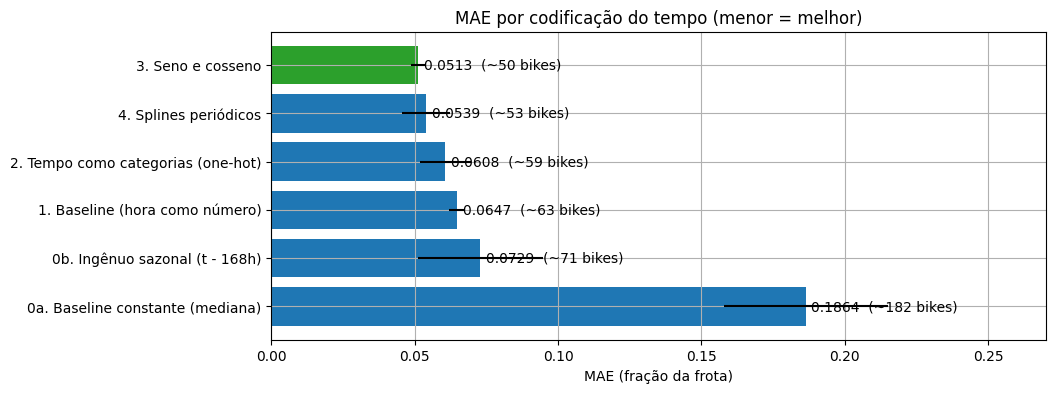

In [272]:
fig, ax = plt.subplots(figsize=(10, 4))
ordenado = tabela.sort_values("MAE", ascending=False)
ax.barh(ordenado.index, ordenado["MAE"], xerr=ordenado["desvio"],
        color=["tab:green" if v == ordenado["MAE"].min() else "tab:blue"
               for v in ordenado["MAE"]])
for i, (v, b) in enumerate(zip(ordenado["MAE"], ordenado["erro em bicicletas"])):
    ax.text(v + 0.002, i, f"{v:.4f}  (~{b:.0f} bikes)", va="center", fontsize=10)
_ = ax.set(title="MAE por codificação do tempo (menor = melhor)",
           xlabel="MAE (fração da frota)", xlim=(0, ordenado["MAE"].max() * 1.45))

### 💬 Discussão em aula

Compare as linhas da tabela e responda:

1. **Quanto o baseline perdeu por tratar a hora como número puro?**
   Converta a diferença de MAE em bicicletas por hora — é dinheiro de operação.
2. **Por que o one-hot melhora, mas não é o melhor?**
   Ele conserta a falsa ordem, mas joga fora a vizinhança (8h e 9h ficam sem relação).
3. **Trigonométrico vs. splines**: nesta configuração de rede os dois ficam próximos.
   O sen/cos é mais econômico (2 colunas por ciclo); os splines são mais flexíveis
   (12 colunas para a hora). Com uma rede pequena como a nossa, a economia ajuda;
   com modelos lineares (FASE 4 (§4.1)), os splines vencem com folga.
4. **Olhe o "gap treino → teste"** de cada modelo. Quem está decorando os dados?
5. **Compare tudo com os baselines do §2.4.** O baseline constante erra ~182 bicicletas e o
   ingênuo sazonal ~71. Quanto do ganho total veio de "usar um modelo" e quanto veio de
   "codificar o tempo direito"?

---
---

# 🔬 FASE 4 — DIAGNÓSTICO: por que o melhor modelo é melhor?

Ter o número não basta: precisamos **entender** o resultado. Esta fase responde a duas perguntas:

- **§4.1** — O ganho veio da rede neural ou da codificação? (o teste do achado 7: interações)
- **§4.2** — Onde, exatamente, o modelo ainda erra?

---
## §4.1 — Linear vs. Rede Neural: quem aprende as **interações**?

Aqui está o ponto mais interessante da comparação com o exemplo original do scikit-learn.

Lembre da FASE 1 (§1.4): **a curva da hora é diferente em dia útil e em fim de semana**
(dois picos vs. um pico). Isso é uma **interação** entre `hour` e `workingday`.

Um **modelo linear** (Ridge) só sabe somar efeitos:

$$ \hat{y} = w_1 \cdot f(\text{hora}) + w_2 \cdot g(\text{dia útil}) + \dots $$

Ele aprende **um único formato de curva de hora**, que depois só é deslocado para cima
ou para baixo pelo dia da semana. Ele **não consegue** ter dois formatos diferentes.

Por isso o exemplo original precisa do `Nystroem` — uma aproximação de **kernel polinomial**
que cria artificialmente os produtos entre atributos (`hora_spline × workingday`),
para só então alimentar o modelo linear.

**A rede neural não precisa disso.** Cada neurônio da camada oculta é uma combinação de
*todas* as entradas passada por uma não linearidade — as interações emergem do treinamento.

Vamos comprovar isso com números, usando **exatamente os mesmos atributos de splines**
nos três modelos:

In [273]:
from sklearn.linear_model import RidgeCV
from sklearn.kernel_approximation import Nystroem

alphas = np.logspace(-6, 6, 25)

# (a) Modelo LINEAR com splines: só soma efeitos, sem interações
modelo_ridge = make_pipeline(preproc_splines, RidgeCV(alphas=alphas))
_ = avaliar(modelo_ridge, "5. Ridge + splines (linear, SEM interações)")

===== 5. Ridge + splines (linear, SEM interações) =====
MAE  teste : 0.0975 +/- 0.0114   (~95 bicicletas de erro por hora)
RMSE teste : 0.1321 +/- 0.0127
MAE treino : 0.0763   (gap treino->teste = +0.0211)


In [274]:
# (b) Modelo LINEAR + kernel: o Nystroem fabrica os produtos entre atributos
modelo_ridge_kernel = make_pipeline(
    preproc_splines,
    Nystroem(kernel="poly", degree=2, n_components=300, random_state=0),
    RidgeCV(alphas=alphas),
)
_ = avaliar(modelo_ridge_kernel, "6. Ridge + splines + Nystroem (interações fabricadas)")

===== 6. Ridge + splines + Nystroem (interações fabricadas) =====
MAE  teste : 0.0739 +/- 0.0406   (~72 bicicletas de erro por hora)
RMSE teste : 0.1002 +/- 0.0448
MAE treino : 0.0367   (gap treino->teste = +0.0372)


In [275]:
# (c) Comparação final: linear puro x linear com kernel x rede neural
comparacao = pd.DataFrame(resultados).T.loc[[
    "5. Ridge + splines (linear, SEM interações)",
    "6. Ridge + splines + Nystroem (interações fabricadas)",
    "4. Splines periódicos",
]][["MAE", "erro em bicicletas"]].round(4)
comparacao.index = ["Ridge (linear)", "Ridge + Nystroem", "MLP (rede neural)"]
comparacao

,MAE,erro em bicicletas
Ridge (linear),0.0975,95.2175
Ridge + Nystroem,0.0739,72.1572
MLP (rede neural),0.0539,52.7061


### 🧠 A moral da história

1. **Ridge puro** é o pior: mesmo com os splines perfeitos, ele não representa a
   interação hora × dia útil.
2. **Ridge + Nystroem** melhora bastante — o kernel entrega as interações prontas.
   Mas isso é trabalho manual do cientista de dados, com custo computacional e mais
   hiperparâmetros para ajustar.
3. **A MLP** chega mais longe **sem nenhum truque**: as camadas ocultas aprendem as
   interações sozinhas.

> **Então a engenharia de atributos não importa para redes neurais?**
> Importa, sim — e a FASE 3 (§3.5) provou isso: só mudando a codificação do tempo,
> o erro da MESMA rede caiu de forma expressiva.
> A rede aprende **interações** sozinha; mas ela não adivinha que 23h e 0h são vizinhos.
> Essa informação é **estrutura do problema**, e entregá-la de graça economiza
> capacidade da rede e dados de treino.

---
## §4.2 — Análise qualitativa das previsões

Métrica agregada esconde detalhe. Vamos **olhar as previsões** do pior e do melhor
modelo no último período de teste.

In [276]:
# Treinamos no último split e prevemos o período de teste correspondente
idx_treino, idx_teste = todos_splits[-1]

modelo_baseline.fit(X.iloc[idx_treino], y.iloc[idx_treino])
pred_baseline = modelo_baseline.predict(X.iloc[idx_teste])

modelo_trigonometrico.fit(X.iloc[idx_treino], y.iloc[idx_treino])
pred_trig = modelo_trigonometrico.predict(X.iloc[idx_teste])

y_real = y.iloc[idx_teste].to_numpy()
print("Horas no conjunto de teste:", len(y_real))

Horas no conjunto de teste: 1000


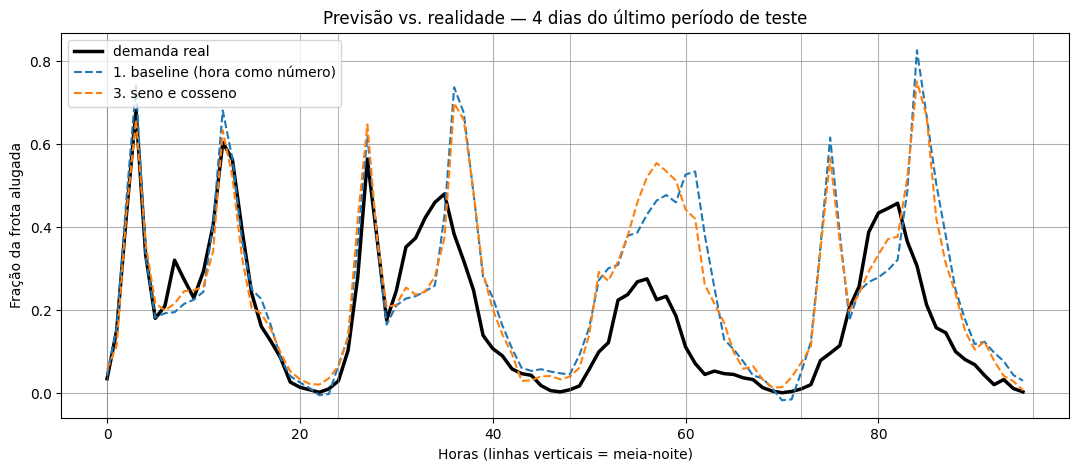

In [277]:
# Zoom em 4 dias (96 horas) para enxergar o formato das curvas
n = 96
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_real[:n], "k-", lw=2.5, label="demanda real")
ax.plot(pred_baseline[:n], "--", label="1. baseline (hora como número)")
ax.plot(pred_trig[:n], "--", label="3. seno e cosseno")
for dia in range(0, n + 1, 24):
    ax.axvline(dia, color="gray", lw=0.7, alpha=0.6)
_ = ax.set(title="Previsão vs. realidade — 4 dias do último período de teste",
           xlabel="Horas (linhas verticais = meia-noite)",
           ylabel="Fração da frota alugada")
_ = ax.legend()

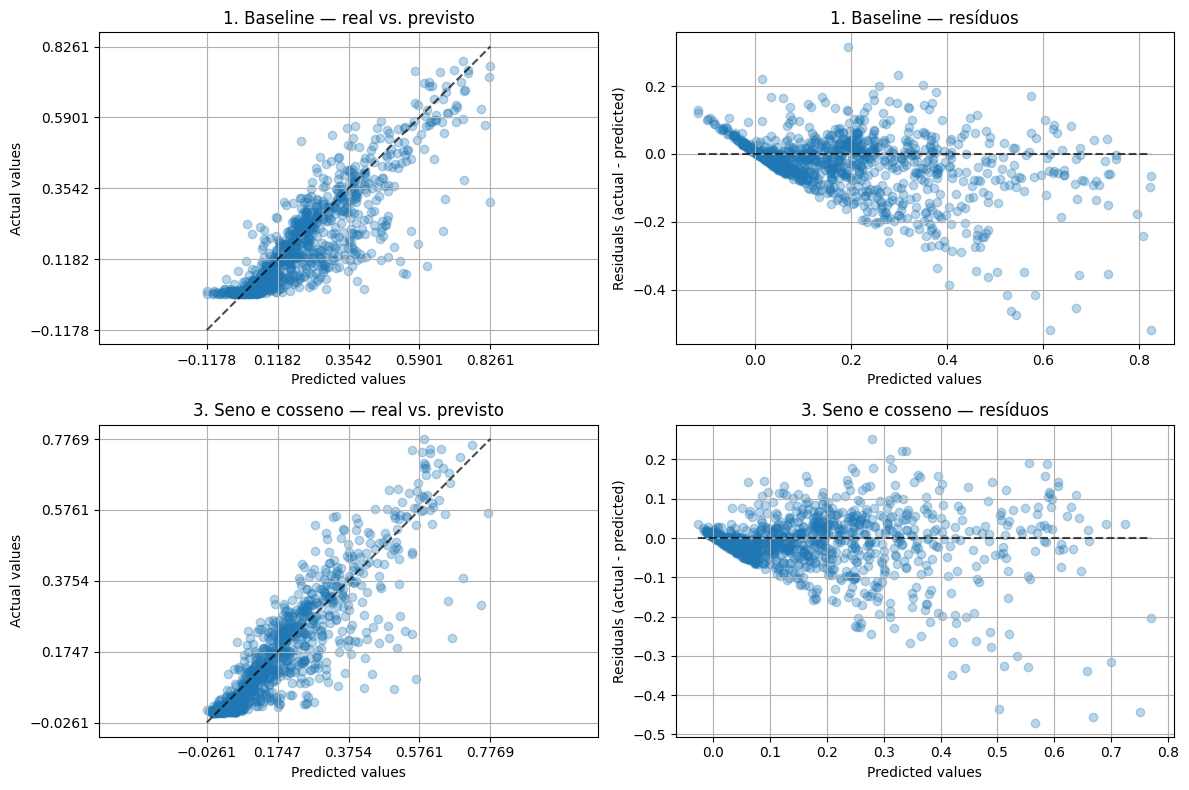

In [278]:
# Erro de previsão: previsto vs. real e resíduos
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for linha, (nome, pred) in enumerate([("1. Baseline", pred_baseline),
                                      ("3. Seno e cosseno", pred_trig)]):
    PredictionErrorDisplay.from_predictions(
        y_real, pred, kind="actual_vs_predicted", ax=axs[linha, 0], scatter_kwargs={"alpha": 0.3}
    )
    axs[linha, 0].set_title(f"{nome} — real vs. previsto")
    PredictionErrorDisplay.from_predictions(
        y_real, pred, kind="residual_vs_predicted", ax=axs[linha, 1], scatter_kwargs={"alpha": 0.3}
    )
    axs[linha, 1].set_title(f"{nome} — resíduos")
plt.tight_layout()

### O que procurar nesses gráficos

- **Real vs. previsto**: quanto mais os pontos colam na diagonal, melhor.
  Repare que os dois modelos **subestimam os picos** (pontos acima da diagonal na parte alta):
  é a assimetria do alvo que vimos na FASE 1 (§1.3).
- **Resíduos**: o ideal é uma nuvem sem formato, centrada em zero. Qualquer padrão
  (funil, curva, faixas) indica estrutura que o modelo **não** capturou.
- **Previsões negativas**: a rede pode prever demanda negativa, o que é impossível na prática.
  Isso vira um dos exercícios.

---
---

# 🏁 FASE 5 — FECHAMENTO

---
## Conclusões

1. **A representação da entrada vale tanto quanto o modelo.** Trocando apenas a codificação
   do tempo — mesma rede, mesmos dados, mesma validação — o erro caiu de forma expressiva.

2. **Variável cíclica como número puro é um bug silencioso.** O modelo não reclama,
   apenas fica pior. `hour`, `weekday`, `month`, ângulos, direção do vento, dias do ano:
   todos sofrem do mesmo problema.

3. **Três receitas para variáveis cíclicas:**
   - *one-hot*: conserta a falsa ordem, mas descarta a vizinhança;
   - *seno/cosseno*: barato (2 colunas) e fecha o círculo; ideal para padrões suaves;
   - *splines periódicos*: mais colunas, mas capturam padrões locais e pontiagudos.

4. **Séries temporais exigem validação temporal.** `TimeSeriesSplit` com `gap`,
   nunca `KFold` embaralhado.

5. **A rede neural aprende interações sozinha**, o que modelos lineares só conseguem
   com kernels ou termos de produto criados na mão. Mas ela **não** adivinha a estrutura
   cíclica — essa você entrega.

6. **Pipeline não é firula.** É o que garante que o `StandardScaler` e o `OneHotEncoder`
   sejam ajustados só com dados de treino dentro de cada rodada da validação cruzada.

---
## Exercícios propostos

**Nível 1 — variações diretas**

1. Aumente a rede para `hidden_layer_sizes=(128, 64)` e reavalie os 4 modelos.
   A vantagem da codificação cíclica **aumenta ou diminui** com uma rede maior? Por quê?
2. Varie `n_splines` da hora (4, 8, 12, 24) no Modelo 4 e plote o MAE em função desse valor.
   Existe um ponto ótimo? O que acontece com 24 splines?
3. Remova `early_stopping` (deixe `False`, `max_iter=500`) e observe o
   "gap treino → teste". O que isso demonstra?

**Nível 2 — engenharia de atributos**

4. **Combine** as codificações: splines para `hour` + seno/cosseno para `month`.
   Melhora?
5. A previsão pode ficar negativa. Envolva a rede em um
   `TransformedTargetRegressor` com `func=np.sqrt` / `inverse_func=np.square`,
   ou simplesmente aplique `np.clip(pred, 0, None)`. Qual o efeito no MAE?
6. Crie explicitamente o atributo de interação `hour × workingday` (por exemplo,
   multiplicando as colunas de spline da hora pela coluna `workingday`) e verifique
   se a MLP melhora. Se não melhorar, você acabou de confirmar a FASE 4 (§4.1).

**Nível 3 — investigação**

7. Troque a MLP por `HistGradientBoostingRegressor` usando o baseline ingênuo.
   Árvores sofrem com variáveis cíclicas? Explique o resultado pela forma como uma
   árvore particiona o espaço.
8. Use `GridSearchCV` com `cv=ts_cv` para ajustar `hidden_layer_sizes`, `alpha`
   e `learning_rate_init` no melhor pré-processamento. Cuidado com o custo!
9. Refaça toda a análise prevendo a demanda **6 horas à frente** (`y.shift(-6)`).
   O que muda nas conclusões?